## 01. Importing core libraries & loading final dataset

In [1]:
# importing the core libraries and adjusting the settings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from IPython.display import display


# setting style for visualizations
sns.set_theme(style="darkgrid")

# limiting scientific notation
pd.set_option("display.float_format", "{:.4f}".format)

# displaying all columns available
pd.set_option("display.max_columns", None)

In [2]:
# loading dataset prepared for modeling

df = pd.read_csv("../01_data/03_modeling/rossmann_dataset_for_modeling_final.csv") 
df.head()

,Store,Date,Sales,Sales_log,StoreType,Assortment,Promo,Promo_Start,Promo_Start_Tomorrow,Promo_End,Promo_End_Yesterday,Promo_Duration_Days,Promo2_Active,Promo2_Duration_Days,Promo2Renewal,Competition_Exists,Competition_Existence_Days,Competition_Existence_Days_clip,CompetitionDistance_v2,DayOfWeek,week_of_month,is_month_begin,is_month_end,month_of_year,quarter_of_year,open_closed_tomorrow,open_closed_yesterday,Hol_Any,Hol_Christmas_1w,Hol_Christmas_2w,Hol_Christmas_3w,Hol_Easter_1w,Hol_Easter_2w,Hol_Easter_3w,Hol_Special_Event,SchoolHoliday,SchoolHoliday_Only,Sales_lag_1,Sales_lag_7,Sales_lag_14,Sales_lag_28,Sales_rolling_mean_7,Sales_rolling_mean_14,Sales_rolling_mean_28,Sales_log_lag_1,Sales_log_lag_7,Sales_log_lag_14,Sales_log_lag_28,Sales_log_rolling_mean_7,Sales_log_rolling_mean_14,Sales_log_rolling_mean_28,assigned_land,is_cold_day,is_warm_day,is_hot_day,is_rainy_sum,is_rainy_time,is_rainy_time2
0,1,2013-01-02,5530,8.6181,type_C,basic,0,0,0,0,0,NaN,0,NaN,0,1,1584.0000,1584.0000,1270.0000,Wednesday,1,1,0,1,1,0,1,0,0,0,0,0,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HE,0,0,0,0,0,0
1,1,2013-01-03,4327,8.3729,type_C,basic,0,0,0,0,0,NaN,0,NaN,0,1,1585.0000,1585.0000,1270.0000,Thursday,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,5530.0000,NaN,NaN,NaN,NaN,NaN,NaN,8.6181,NaN,NaN,NaN,NaN,NaN,NaN,HE,0,0,0,0,0,0
2,1,2013-01-04,4486,8.4089,type_C,basic,0,0,0,0,0,NaN,0,NaN,0,1,1586.0000,1586.0000,1270.0000,Friday,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,4327.0000,NaN,NaN,NaN,NaN,NaN,NaN,8.3729,NaN,NaN,NaN,NaN,NaN,NaN,HE,0,0,0,0,0,0
3,1,2013-01-05,4997,8.5168,type_C,basic,0,0,1,0,0,NaN,0,NaN,0,1,1587.0000,1587.0000,1270.0000,Saturday,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,4486.0000,NaN,NaN,NaN,NaN,NaN,NaN,8.4089,NaN,NaN,NaN,NaN,NaN,NaN,HE,0,0,0,0,0,0
4,1,2013-01-07,7176,8.8786,type_C,basic,1,1,0,0,0,1.0000,0,NaN,0,1,1589.0000,1589.0000,1270.0000,Monday,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,4997.0000,NaN,NaN,NaN,NaN,NaN,NaN,8.5168,NaN,NaN,NaN,NaN,NaN,NaN,HE,0,0,0,0,0,0


In [3]:
# minor data types adjustment

df["Date"] = pd.to_datetime(df["Date"])

cat_cols = ['Store', 'StoreType', 'Assortment', 'DayOfWeek', 'week_of_month', 'month_of_year', 'quarter_of_year', 'assigned_land']
df[cat_cols] = df[cat_cols].astype("category")

In [4]:
# basic information about the final dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 844392 entries, 0 to 844391
Data columns (total 58 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   Store                            844392 non-null  category      
 1   Date                             844392 non-null  datetime64[us]
 2   Sales                            844392 non-null  int64         
 3   Sales_log                        844392 non-null  float64       
 4   StoreType                        844392 non-null  category      
 5   Assortment                       844392 non-null  category      
 6   Promo                            844392 non-null  int64         
 7   Promo_Start                      844392 non-null  int64         
 8   Promo_Start_Tomorrow             844392 non-null  int64         
 9   Promo_End                        844392 non-null  int64         
 10  Promo_End_Yesterday              844392 non-null  int64

In [5]:
# reminder that missing values were intentionally not imputed - they will be handled differently depending on the algorithm

# we have them for: Promo_Duration_Days, Promo2_Duration_Days, Competition_Existence_Days / Competition_Existence_Days_clip, CompetitonDistance_v2, and for Sales lags/rolling means

df.isna().mean() * 100

Store                              0.0000
Date                               0.0000
Sales                              0.0000
Sales_log                          0.0000
StoreType                          0.0000
Assortment                         0.0000
Promo                              0.0000
Promo_Start                        0.0000
Promo_Start_Tomorrow               0.0000
Promo_End                          0.0000
Promo_End_Yesterday                0.0000
Promo_Duration_Days               55.3648
Promo2_Active                      0.0000
Promo2_Duration_Days              56.9121
Promo2Renewal                      0.0000
Competition_Exists                 0.0000
Competition_Existence_Days        40.1886
Competition_Existence_Days_clip   40.1886
CompetitionDistance_v2             8.3028
DayOfWeek                          0.0000
week_of_month                      0.0000
is_month_begin                     0.0000
is_month_end                       0.0000
month_of_year                     

## 02. Spliting data into train / test sets & defining functions for model evaluation

In [6]:
# copy of the dataframe

df_model = df.copy()
df_model.head(3)

,Store,Date,Sales,Sales_log,StoreType,Assortment,Promo,Promo_Start,Promo_Start_Tomorrow,Promo_End,Promo_End_Yesterday,Promo_Duration_Days,Promo2_Active,Promo2_Duration_Days,Promo2Renewal,Competition_Exists,Competition_Existence_Days,Competition_Existence_Days_clip,CompetitionDistance_v2,DayOfWeek,week_of_month,is_month_begin,is_month_end,month_of_year,quarter_of_year,open_closed_tomorrow,open_closed_yesterday,Hol_Any,Hol_Christmas_1w,Hol_Christmas_2w,Hol_Christmas_3w,Hol_Easter_1w,Hol_Easter_2w,Hol_Easter_3w,Hol_Special_Event,SchoolHoliday,SchoolHoliday_Only,Sales_lag_1,Sales_lag_7,Sales_lag_14,Sales_lag_28,Sales_rolling_mean_7,Sales_rolling_mean_14,Sales_rolling_mean_28,Sales_log_lag_1,Sales_log_lag_7,Sales_log_lag_14,Sales_log_lag_28,Sales_log_rolling_mean_7,Sales_log_rolling_mean_14,Sales_log_rolling_mean_28,assigned_land,is_cold_day,is_warm_day,is_hot_day,is_rainy_sum,is_rainy_time,is_rainy_time2
0,1,2013-01-02,5530,8.6181,type_C,basic,0,0,0,0,0,NaN,0,NaN,0,1,1584.0000,1584.0000,1270.0000,Wednesday,1,1,0,1,1,0,1,0,0,0,0,0,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HE,0,0,0,0,0,0
1,1,2013-01-03,4327,8.3729,type_C,basic,0,0,0,0,0,NaN,0,NaN,0,1,1585.0000,1585.0000,1270.0000,Thursday,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,5530.0000,NaN,NaN,NaN,NaN,NaN,NaN,8.6181,NaN,NaN,NaN,NaN,NaN,NaN,HE,0,0,0,0,0,0
2,1,2013-01-04,4486,8.4089,type_C,basic,0,0,0,0,0,NaN,0,NaN,0,1,1586.0000,1586.0000,1270.0000,Friday,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,4327.0000,NaN,NaN,NaN,NaN,NaN,NaN,8.3729,NaN,NaN,NaN,NaN,NaN,NaN,HE,0,0,0,0,0,0


In [7]:
# checking how to divide the dataset to maintain 6-week forecast horizon (42 days ahead)

# test set cut-off date
print(df_model["Date"].max() - pd.to_timedelta(42, unit = "D")) 

2015-06-19 00:00:00


In [8]:
# observations before 2015-06-19 should go to the train test, while observations from 2015-06-19 should be included in the test set.

# train set (model fit, hyperparamter tuning)
train_df = df_model[df_model["Date"] < "2015-06-19"] 

# test set (model comparison & selection, final assessment of the best model)
test_df = df_model[df_model["Date"] >= "2015-06-19"] 

In [9]:
# sanity check - train period & test period

print(f"Start date for the training set: {train_df["Date"].min()}")
print(f"End date for the training set: {train_df["Date"].max()}")
print("--------------------------------------------------------")
print(f"Start date for the testing set: {test_df["Date"].min()}")
print(f"End date for the testing set: {test_df["Date"].max()}")

Start date for the training set: 2013-01-01 00:00:00
End date for the training set: 2015-06-18 00:00:00
--------------------------------------------------------
Start date for the testing set: 2015-06-19 00:00:00
End date for the testing set: 2015-07-31 00:00:00


In [10]:
### FUNCTIONS FOR MODEL EVALUATION ### 

# we will look at a total of 4 measures - R2, MAE, RMSE and RMSPE, but the main evaluation metric will be RMSPE (same as used by Rossmann in offical modeling competition)
# note: we predict Sales_log, but want to evaluate model on the original Sales scale


# help function for rmspe calculation

from sklearn.metrics import make_scorer

def rmspe_log(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mask = y_true != 0

    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

rmspe_scorer = make_scorer(rmspe_log, greater_is_better=False)

# function for all metrics calculation

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def calculate_metrics(y_true_log, y_pred_log):

    y_pred_log = pd.Series(y_pred_log, index=y_true_log.index) # converting to Series if needed

    valid = y_true_log.notna() & y_pred_log.notna() # handling missing values

    # back transformation to original Sales scale
    y_true = np.expm1(y_true_log[valid])
    y_pred = np.expm1(y_pred_log[valid])
    
    # metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mask = y_true != 0
    rmspe = np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

    return {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "RMSPE": rmspe
    }

# function for model evaluation

def evaluate_model(y_true_log, y_pred_log, model_name):

    metrics = calculate_metrics(
        y_true_log,
        y_pred_log)

    return pd.DataFrame({
        "Model": [model_name],
        "R2": [metrics["R2"]],
        "MAE": [metrics["MAE"]],
        "RMSE": [metrics["RMSE"]],
        "RMSPE": [metrics["RMSPE"]]
    })

## 03. Baseline Naive Models

In [11]:
# We begin the modeling process by building a set of simple baseline models. Each model uses a single lag or rolling mean target-related feature to predict Sales_log.

# Building baseline models has two main goals:
# 1. They establish a benchmark that more sophisticated models should outperform. 
# 2. They help identify which historical sales features contain the strongest predictive signal and are therefore worth considering in later stages of model development.

In [12]:
# defining target variable and target-related features

target = "Sales_log" 

features= ['Sales_log_lag_1','Sales_log_lag_7','Sales_log_lag_14','Sales_log_lag_28', 'Sales_log_rolling_mean_7','Sales_log_rolling_mean_14','Sales_log_rolling_mean_28' ]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [13]:
baseline_predictions = {
    "Lag-1": test_df["Sales_log_lag_1"],
    "Lag-7": test_df["Sales_log_lag_7"],
    "Lag-14": test_df["Sales_log_lag_14"],
    "Lag-28": test_df["Sales_log_lag_28"],

    "RollingMean-7": test_df["Sales_log_rolling_mean_7"],
    "RollingMean-14": test_df["Sales_log_rolling_mean_14"],
    "RollingMean-28": test_df["Sales_log_rolling_mean_28"]
}

baseline_results = []

# evaluation of baseline models
for model_name, y_pred in baseline_predictions.items():
    results = evaluate_model(y_test, y_pred, model_name)
    baseline_results.append(results)

baseline_results_df = pd.concat(baseline_results, ignore_index=True)
baseline_results_df = baseline_results_df.sort_values(by="RMSE")

baseline_results_df

,Model,R2,MAE,RMSE,RMSPE
5,RollingMean-14,0.6399,1306.4945,1826.7723,0.2835
6,RollingMean-28,0.6262,1369.1701,1861.1665,0.2965
0,Lag-1,0.5681,1297.3597,2000.3894,0.3070
4,RollingMean-7,0.5092,1538.9608,2132.5828,0.3201
2,Lag-14,0.3588,1767.5803,2437.5575,0.3765
3,Lag-28,0.1761,2144.3905,2762.9714,0.4730
1,Lag-7,0.0033,2400.0968,3038.9782,0.4846


In [14]:
test_df[["Sales_log", "Sales_log_lag_7", "Sales_log_lag_1" , "Sales_log_rolling_mean_14"]].corr()

,Sales_log,Sales_log_lag_7,Sales_log_lag_1,Sales_log_rolling_mean_14
Sales_log,1.0000,0.4648,0.7303,0.7865
Sales_log_lag_7,0.4648,1.0000,0.6008,0.7743
Sales_log_lag_1,0.7303,0.6008,1.0000,0.8235
Sales_log_rolling_mean_14,0.7865,0.7743,0.8235,1.0000


### **Key takeaways:**

- Among the **rolling-based baselines**, `Sales_log_rolling_mean_14` achieved the **strongest performance (R² = 0.64, RMSPE = 0.28)**, while among the **lag-based baselines** the best results were obtained for `Sales_log_lag_1` **(R² = 0.57, RMSPE = 0.31)**. These findings are **consistent with the earlier correlation analysis**, where both features exhibited the strongest relationships with `Sales_log`.

- Interestingly, `Sales_log_lag_7` performed substantially worse than the remaining lag features. This observation also **aligns with the multivariate analysis**, where the weekly lag displayed the weakest correlation with the target variable.

- The results suggest that **recent sales dynamics and short-term trends** contain considerably more predictive information than weekly sales patterns, making `Sales_log_lag_1` and `Sales_log_rolling_mean_14` the most promising candidates for modeling.

- Baseline models were evaluated on the **same hold-out test period as the final ML models**. This provides a **direct benchmark for assessing whether more advanced approaches deliver meaningful improvements** over simple historical-based forecasting rules.

## 04. ML Pipeline for Linear Models

In [15]:
# copies of the train & test sets for linear models 

train_df_lr = train_df.copy()
test_df_lr = test_df.copy()

In [16]:
# handling missing values (required for linear models) 

# removing the initial 14 observations where we do not have a rolling mean from the last 14 days (and lag from the last day)

train_df_lr = train_df_lr.dropna(subset = ["Sales_log_lag_1", "Sales_log_rolling_mean_14"])

# filling in missing data for features related to Promo, Promo2 and Competition

for dataset in [train_df_lr, 
                test_df_lr]:

    # since Promo2 is not active (Promo2_Active == 0), it lasts 0 days 
    dataset["Promo2_Duration_Days"] = dataset["Promo2_Duration_Days"].fillna(0) 

    # since Competition does not exist (Competition_Exists == 0), it exists 0 days
    dataset["Competition_Existence_Days"] = dataset["Competition_Existence_Days"].fillna(0)
    dataset["Competition_Existence_Days_clip"] = dataset["Competition_Existence_Days_clip"].fillna(0)

    # if the distance to the Competition is not known, we impute the missing values with the median (calculated based on the training set to avoid data leakage)
    dataset["CompetitionDistance_v2"] = dataset["CompetitionDistance_v2"].fillna(train_df_lr["CompetitionDistance_v2"].median())

    # since Promo is not active (Promo == 0), it lasts 0 days
    dataset["Promo_Duration_Days"] = dataset["Promo_Duration_Days"].fillna(0)


In [17]:
# defining numerical, binary, and categorical features for linear models

num_features_linear = [
                'Promo_Duration_Days',               
                'Promo2_Duration_Days', 
                'Competition_Existence_Days', 
                # 'Competition_Existence_Days_clip',  # works similarily to original Competition_Existence_Days version
                'CompetitionDistance_v2',
                'Sales_log_lag_1', 
                # 'Sales_log_lag_7',
                # 'Sales_log_lag_14',
                # 'Sales_log_lag_28',
                # 'Sales_log_rolling_mean_7',
                'Sales_log_rolling_mean_14',        
                # 'Sales_log_rolling_mean_28'
]

binary_features_linear = [
                   'Promo', 
                   'Promo_Start',
                   'Promo_Start_Tomorrow',
                   'Promo_End',
                   'Promo_End_Yesterday',
                   'Promo2_Active', 
                   'Promo2Renewal', 
                   'Competition_Exists', 
                   'is_month_begin', 
                   'is_month_end',
                   'open_closed_tomorrow',
                   'open_closed_yesterday',
                   'Hol_Any', 
                   'Hol_Christmas_1w', 
                   'Hol_Christmas_2w', 
                   'Hol_Christmas_3w', 
                   'Hol_Easter_1w', 
                   'Hol_Easter_2w',
                   'Hol_Easter_3w', 
                   'Hol_Special_Event',
                   'SchoolHoliday', 
                   # 'SchoolHoliday_Only',    # works similarily to original SchoolHoliday version

                   # 'is_cold_day',           # does not really infuence the model performance
                   # 'is_warm_day',           # does not really infuence the model performance
                   # 'is_hot_day',            # does not really infuence the model performance
                   # 'is_rainy_sum',          # does not really infuence the model performance
                   # 'is_rainy_time',         # does not really infuence the model performance
                   # 'is_rainy_time2'         # does not really infuence the model performance
]

cat_features_linear = [
                'StoreType', 
                'Assortment', 
                'DayOfWeek', 
                'week_of_month', 
                'month_of_year', 
                'quarter_of_year',
                'assigned_land'
]

features_linear = (
    num_features_linear +
    binary_features_linear +
    cat_features_linear
)

In [18]:
target = "Sales_log"

X_train = train_df_lr[features_linear]
y_train = train_df_lr[target]

X_test = test_df_lr[features_linear]
y_test = test_df_lr[target]

In [19]:
### PREPROCESSING PIPELINE ###

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Standardization for numerical features (Z-score)
num_transformer = Pipeline([
    ("scaler", StandardScaler())
])

# OneHot Encoding for categorical features
cat_transformer = Pipeline([
    ("onehot", OneHotEncoder(
        drop="first",
        handle_unknown="ignore") # unseen category combinations may appear in future periods
    )
])

# ColumnTransformer
preprocessor_linear = ColumnTransformer([
    ("num", num_transformer, num_features_linear),
    ("cat", cat_transformer, cat_features_linear)
], remainder="passthrough" # binary features (0/1) without any changes (no need of standardization)
)

## 05. Linear Regression models

### 5.1. Linear Regression without regularization

In [20]:
from sklearn.linear_model import LinearRegression

pipeline_lr = Pipeline([
    ("preprocessor", preprocessor_linear),
    ("model", LinearRegression())
])

pipeline_lr.fit(X_train, y_train)

y_pred_lr = pipeline_lr.predict(X_test)

In [21]:
results_lr = evaluate_model(
    y_test,
    pd.Series(y_pred_lr, index=y_test.index),
    "Linear Regression"
)

results_lr

,Model,R2,MAE,RMSE,RMSPE
0,Linear Regression,0.8501,797.1301,1178.3889,0.1835


### 5.2. Ridge Regression (L2 norm regularization)

In [122]:
# Ridge Regression - adding penalty in the form of the L2 norm (sum of squared coefficients) to the cost function

from sklearn.linear_model import Ridge

pipeline_ridge = Pipeline([
    ("preprocessor", preprocessor_linear),
    ("model", Ridge())
])

pipeline_ridge.fit(X_train, y_train)

y_pred_ridge = pipeline_ridge.predict(X_test)

In [123]:
results_ridge = evaluate_model(
    y_test,
    pd.Series(y_pred_ridge, index = y_test.index),
    "Ridge"
)

results_ridge

,Model,R2,MAE,RMSE,RMSPE
0,Ridge,0.8501,797.1232,1178.3775,0.1835


In [124]:
### HYPERPARAMETER TUNING FOR RIDGE REGRESSION ###

# TimeSeriesSplit for Cross-validation
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV

# TimeSeriesSplit will be used to avoid data leakage and ensure chronology
tscv = TimeSeriesSplit(n_splits=5)

from scipy.stats import loguniform

param_grid_ridge = {
    "model__alpha": loguniform(1e-4, 100)
}

random_search_ridge = RandomizedSearchCV(
    estimator=pipeline_ridge,
    param_distributions=param_grid_ridge,
    n_iter=20,
    scoring=rmspe_scorer,  # we want to minimalize RMSPE
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_ridge.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ..................model__alpha=0.017670169402947963; total time=   1.2s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .....................model__alpha=50.61576888752309; total time=   1.2s
[CV] END .....................model__alpha=50.61576888752309; total time=   1.7s
[CV] END ..................model__alpha=0.017670169402947963; total time=   1.9s
[CV] END ..................model__alpha=0.017670169402947963; total time=   2.8s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .....................model__alpha=50.61576888752309; total time=   2.8s
[CV] END .....................model__alpha=2.465832945854912; total time=   0.9s
[CV] END ..................model__alpha=0.017670169402947963; total time=   3.8s
[CV] END .....................model__alpha=2.465832945854912; total time=   1.7s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ...................model__alpha=0.39079671568228835; total time=   1.1s
[CV] END .....................model__alpha=2.465832945854912; total time=   2.2s
[CV] END ..................model__alpha=0.017670169402947963; total time=   5.8s
[CV] END ...................model__alpha=0.39079671568228835; total time=   1.5s
[CV] END .....................model__alpha=50.61576888752309; total time=   4.3s
[CV] END .....................model__alpha=50.61576888752309; total time=   4.5s
[CV] END .....................model__alpha=2.465832945854912; total time=   3.1s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .................model__alpha=0.0008632008168602544; total time=   1.0s
[CV] END ...................model__alpha=0.39079671568228835; total time=   2.7s
[CV] END .................model__alpha=0.0008632008168602544; total time=   2.2s
[CV] END .....................model__alpha=2.465832945854912; total time=   5.2s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .................model__alpha=0.0008629132190071859; total time=   1.1s
[CV] END ...................model__alpha=0.39079671568228835; total time=   3.8s
[CV] END .................model__alpha=0.0008632008168602544; total time=   2.8s
[CV] END .................model__alpha=0.0008629132190071859; total time=   1.7s
[CV] END ...................model__alpha=0.39079671568228835; total time=   4.3s
[CV] END .................model__alpha=0.0008632008168602544; total time=   3.7s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ................model__alpha=0.00022310108018679258; total time=   1.0s
[CV] END .................model__alpha=0.0008629132190071859; total time=   2.1s
[CV] END .................model__alpha=0.0008632008168602544; total time=   4.0s
[CV] END ................model__alpha=0.00022310108018679258; total time=   1.5s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ....................model__alpha=15.741890047456648; total time=   1.1s
[CV] END .................model__alpha=0.0008629132190071859; total time=   3.0s
[CV] END ................model__alpha=0.00022310108018679258; total time=   2.6s
[CV] END ....................model__alpha=15.741890047456648; total time=   1.9s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ....................model__alpha=0.4042872735027334; total time=   1.2s
[CV] END .................model__alpha=0.0008629132190071859; total time=   5.4s
[CV] END ....................model__alpha=15.741890047456648; total time=   3.2s
[CV] END ................model__alpha=0.00022310108018679258; total time=   4.3s
[CV] END ....................model__alpha=0.4042872735027334; total time=   1.8s
[CV] END ................model__alpha=0.00022310108018679258; total time=   4.5s
[CV] END ....................model__alpha=15.741890047456648; total time=   3.3s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ....................model__alpha=1.7718847354806828; total time=   1.3s
[CV] END ....................model__alpha=15.741890047456648; total time=   4.1s
[CV] END ....................model__alpha=0.4042872735027334; total time=   2.4s
[CV] END ....................model__alpha=1.7718847354806828; total time=   1.8s
[CV] END ....................model__alpha=1.7718847354806828; total time=   2.2s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ................model__alpha=0.00013289448722869195; total time=   1.0s
[CV] END ....................model__alpha=0.4042872735027334; total time=   3.5s
[CV] END ................model__alpha=0.00013289448722869195; total time=   2.1s
[CV] END ....................model__alpha=1.7718847354806828; total time=   3.9s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .....................model__alpha=65.98711072054076; total time=   1.3s
[CV] END ................model__alpha=0.00013289448722869195; total time=   3.0s
[CV] END ....................model__alpha=0.4042872735027334; total time=   5.3s
[CV] END ....................model__alpha=1.7718847354806828; total time=   4.6s
[CV] END .....................model__alpha=65.98711072054076; total time=   2.2s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .....................model__alpha=9.877700294007917; total time=   1.1s
[CV] END ................model__alpha=0.00013289448722869195; total time=   4.5s
[CV] END .....................model__alpha=65.98711072054076; total time=   2.7s
[CV] END ................model__alpha=0.00013289448722869195; total time=   5.0s
[CV] END .....................model__alpha=9.877700294007917; total time=   1.8s
[CV] END .....................model__alpha=65.98711072054076; total time=   2.9s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .................model__alpha=0.0018794668241638478; total time=   0.9s
[CV] END .....................model__alpha=9.877700294007917; total time=   2.0s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .....................model__alpha=65.98711072054076; total time=   4.1s
[CV] END .....................model__alpha=9.877700294007917; total time=   2.6s
[CV] END .................model__alpha=0.0018794668241638478; total time=   1.5s
[CV] END .................model__alpha=0.0012329623163659848; total time=   0.9s
[CV] END .....................model__alpha=9.877700294007917; total time=   3.1s
[CV] END .................model__alpha=0.0018794668241638478; total time=   2.3s
[CV] END .................model__alpha=0.0012329623163659848; total time=   1.7s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .................model__alpha=0.0012601639723276807; total time=   1.1s
[CV] END .................model__alpha=0.0018794668241638478; total time=   3.7s
[CV] END .................model__alpha=0.0012329623163659848; total time=   2.6s
[CV] END .................model__alpha=0.0012601639723276807; total time=   1.8s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ..................model__alpha=0.006690421166498805; total time=   1.0s
[CV] END .................model__alpha=0.0012329623163659848; total time=   3.8s
[CV] END .................model__alpha=0.0018794668241638478; total time=   5.0s
[CV] END .................model__alpha=0.0012601639723276807; total time=   2.6s
[CV] END .................model__alpha=0.0012329623163659848; total time=   4.4s
[CV] END ..................model__alpha=0.006690421166498805; total time=   1.7s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .................model__alpha=0.0012601639723276807; total time=   3.0s
[CV] END ...................model__alpha=0.14077923139972406; total time=   1.1s
[CV] END ..................model__alpha=0.006690421166498805; total time=   2.2s
[CV] END .................model__alpha=0.0012601639723276807; total time=   3.9s
[CV] END ...................model__alpha=0.14077923139972406; total time=   1.8s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ..................model__alpha=0.006690421166498805; total time=   2.9s
[CV] END ..................model__alpha=0.039054412752107935; total time=   1.0s
[CV] END ...................model__alpha=0.14077923139972406; total time=   2.6s
[CV] END ...................model__alpha=0.14077923139972406; total time=   2.9s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ..................model__alpha=0.005589524205217926; total time=   1.0s
[CV] END ..................model__alpha=0.039054412752107935; total time=   1.9s
[CV] END ..................model__alpha=0.006690421166498805; total time=   4.6s
[CV] END ..................model__alpha=0.039054412752107935; total time=   2.3s
[CV] END ...................model__alpha=0.14077923139972406; total time=   3.9s
[CV] END ..................model__alpha=0.005589524205217926; total time=   1.5s
[CV] END ..................model__alpha=0.039054412752107935; total time=   3.2s
[CV] END ..................model__alpha=0.005589524205217926; total time=   2.0s
[CV] END ..................model__alpha=0.039054412752107935; total time=   3.4s
[CV] END ..................model__alpha=0.005589524205217926; total time=   2.3s
[CV] END ..................model__alpha=0.005589524205217926; total time=   2.1s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'model__alpha': <scipy.stats....t 0x2b8dd2510>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(r...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed 

In [125]:
best_ridge = random_search_ridge.best_estimator_

print(random_search_ridge.best_params_)
print(random_search_ridge.best_score_)

{'model__alpha': np.float64(0.00013289448722869195)}
-0.29015520879261764


In [126]:
### MODEL EVALUATION AFTER HYPERPARAMETER TUNING ###

X_test = test_df_lr[features_linear]
y_test = test_df_lr[target]

y_pred_ridge = best_ridge.predict(X_test)

results_ridge = evaluate_model(
    y_test,
    pd.Series(y_pred_ridge, index=y_test.index),
    "Ridge Tuned"
)

results_ridge

,Model,R2,MAE,RMSE,RMSPE
0,Ridge Tuned,0.8501,797.1301,1178.3889,0.1835


In [ ]:
# saving the tuned model as .pkl file

# import joblib

# joblib.dump(best_ridge, "ridge_regression_tuned.pkl")

['ridge_regression_tuned.pkl']

### 5.3. Lasso Regression (L1 norm regularization)

In [127]:
# Lasso Regression - adding pentaly in the form of the L1 norm (sum of absolute values of the coefficients) to the cost function
# this type of regularization enables automatic feature selection

from sklearn.linear_model import Lasso

pipeline_lasso = Pipeline([
    ("preprocessor", preprocessor_linear),
    ("model", Lasso())  # default alpha = 1 
])

pipeline_lasso.fit(X_train, y_train)

y_pred_lasso = pipeline_lasso.predict(X_test)

In [128]:
results_lasso = evaluate_model(
    y_test,
    pd.Series(y_pred_lasso, index = y_test.index),
    "Lasso"
)

results_lasso

,Model,R2,MAE,RMSE,RMSPE
0,Lasso,-0.0428,2198.4274,3108.4755,0.5081


In [46]:
### HYPERPARAMETER TUNING FOR LASSO REGRESSION ### 

param_grid_lasso = {
    "model__alpha": loguniform(1e-5, 1)
}

random_search_lasso = RandomizedSearchCV(
    estimator=pipeline_lasso,
    param_distributions=param_grid_lasso,
    n_iter=20,
    scoring=rmspe_scorer,
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_lasso.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .....................model__alpha=0.566984951147885; total time=   0.9s
[CV] END .....................model__alpha=0.566984951147885; total time=   2.0s
[CV] END .....................model__alpha=0.566984951147885; total time=   3.0s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .................model__alpha=0.0007459343285726547; total time=   3.6s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ....................model__alpha=0.0457056309980145; total time=   1.6s
[CV] END .....................model__alpha=0.566984951147885; total time=   4.1s
[CV] END ....................model__alpha=0.0457056309980145; total time=   2.7s
[CV] END .....................model__alpha=0.566984951147885; total time=   4.5s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ..................model__alpha=0.009846738873614562; total time=   1.7s
[CV] END .................model__alpha=0.0007459343285726547; total time=   9.0s
[CV] END ....................model__alpha=0.0457056309980145; total time=   4.0s
[CV] END ....................model__alpha=0.0457056309980145; total time=   5.3s
[CV] END ..................model__alpha=0.009846738873614562; total time=   3.5s
[CV] END ....................model__alpha=0.0457056309980145; total time=   7.2s
[CV] END ..................model__alpha=0.009846738873614562; total time=   5.3s
[CV] END ..................model__alpha=0.009846738873614562; total time=   6.8s
[CV] END ..................model__alpha=0.009846738873614562; total time=   8.7s
[CV] END .................model__alpha=0.0007459343285726547; total time=  19.8s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ................model__alpha=6.0268891286825045e-05; total time=   8.7s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .................model__alpha=6.025215736203858e-05; total time=   8.6s
[CV] END .................model__alpha=0.0007459343285726547; total time=  29.2s
[CV] END ................model__alpha=6.0268891286825045e-05; total time=  23.2s
[CV] END .................model__alpha=0.0007459343285726547; total time=  37.6s
[CV] END .................model__alpha=6.025215736203858e-05; total time=  24.9s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .................model__alpha=1.951722464144947e-05; total time=  10.5s
[CV] END ................model__alpha=6.0268891286825045e-05; total time=  43.6s
[CV] END .................model__alpha=6.025215736203858e-05; total time=  46.3s
[CV] END .................model__alpha=1.951722464144947e-05; total time=  29.7s
[CV] END ................model__alpha=6.0268891286825045e-05; total time= 1.0min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ...................model__alpha=0.21423021757741043; total time=   1.2s
[CV] END ...................model__alpha=0.21423021757741043; total time=   2.4s
[CV] END ...................model__alpha=0.21423021757741043; total time=   3.3s
[CV] END ...................model__alpha=0.21423021757741043; total time=   4.7s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ..................model__alpha=0.010129197956845729; total time=   2.2s
[CV] END ...................model__alpha=0.21423021757741043; total time=   5.7s
[CV] END ..................model__alpha=0.010129197956845729; total time=   4.0s
[CV] END .................model__alpha=6.025215736203858e-05; total time= 1.0min
[CV] END ..................model__alpha=0.010129197956845729; total time=   6.0s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ..................model__alpha=0.034702669886504146; total time=   1.9s
[CV] END ................model__alpha=6.0268891286825045e-05; total time= 1.3min
[CV] END ..................model__alpha=0.034702669886504146; total time=   2.9s
[CV] END ..................model__alpha=0.010129197956845729; total time=   7.7s
[CV] END ..................model__alpha=0.034702669886504146; total time=   4.1s
[CV] END ..................model__alpha=0.010129197956845729; total time=   9.2s
[CV] END .................model__alpha=1.951722464144947e-05; total time=  53.8s
[CV] END ..................model__alpha=0.034702669886504146; total time=   5.5s
[CV] END ..................model__alpha=0.034702669886504146; total time=   7.6s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ................model__alpha=1.2674255898937214e-05; total time=  10.6s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ....................model__alpha=0.7072114131472232; total time=   1.7s
[CV] END .................model__alpha=6.025215736203858e-05; total time= 1.3min
[CV] END ....................model__alpha=0.7072114131472232; total time=   2.1s
[CV] END ....................model__alpha=0.7072114131472232; total time=   2.8s
[CV] END ....................model__alpha=0.7072114131472232; total time=   3.4s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ....................model__alpha=0.1452824663751603; total time=   1.4s
[CV] END ....................model__alpha=0.7072114131472232; total time=   4.7s
[CV] END ....................model__alpha=0.1452824663751603; total time=   2.3s
[CV] END ....................model__alpha=0.1452824663751603; total time=   3.0s
[CV] END ....................model__alpha=0.1452824663751603; total time=   3.8s
[CV] END ................model__alpha=1.2674255898937214e-05; total time=  27.4s
[CV] END ....................model__alpha=0.1452824663751603; total time=   4.9s
[CV] END .................model__alpha=1.951722464144947e-05; total time= 1.2min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ................model__alpha=0.00011526449540315612; total time=   8.5s
[CV] END ................model__alpha=0.00011526449540315612; total time=  22.4s
[CV] END ................model__alpha=1.2674255898937214e-05; total time=  50.5s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .................model__alpha=8.111941985431919e-05; total time=   8.9s
[CV] END .................model__alpha=1.951722464144947e-05; total time= 1.6min
[CV] END ................model__alpha=0.00011526449540315612; total time=  40.2s
[CV] END ................model__alpha=1.2674255898937214e-05; total time= 1.2min
[CV] END .................model__alpha=8.111941985431919e-05; total time=  22.6s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .................model__alpha=8.260808399079601e-05; total time=   9.0s
[CV] END ................model__alpha=0.00011526449540315612; total time=  56.1s
[CV] END ................model__alpha=1.2674255898937214e-05; total time= 1.5min
[CV] END .................model__alpha=8.260808399079601e-05; total time=  22.3s
[CV] END .................model__alpha=8.111941985431919e-05; total time=  42.8s
[CV] END ................model__alpha=0.00011526449540315612; total time= 1.2min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ................model__alpha=0.00033205591037519585; total time=   7.2s
[CV] END ................model__alpha=0.00033205591037519585; total time=  17.6s
[CV] END .................model__alpha=8.260808399079601e-05; total time=  43.3s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END ...................model__alpha=0.00420515645091387; total time=   1.8s
[CV] END .................model__alpha=8.111941985431919e-05; total time=  60.0s
[CV] END ...................model__alpha=0.00420515645091387; total time=   3.7s
[CV] END ...................model__alpha=0.00420515645091387; total time=   5.8s
[CV] END ................model__alpha=0.00033205591037519585; total time=  31.9s
[CV] END ...................model__alpha=0.00420515645091387; total time=   7.7s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .................model__alpha=0.0014445251022763056; total time=   3.2s
[CV] END .................model__alpha=8.111941985431919e-05; total time= 1.2min
[CV] END ...................model__alpha=0.00420515645091387; total time=   9.6s
[CV] END .................model__alpha=0.0014445251022763056; total time=   7.1s
[CV] END ................model__alpha=0.00033205591037519585; total time=  42.7s
[CV] END .................model__alpha=8.260808399079601e-05; total time=  59.2s
[CV] END .................model__alpha=0.0014445251022763056; total time=  11.6s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END .................model__alpha=0.0002858549394196192; total time=   6.9s
[CV] END .................model__alpha=0.0014445251022763056; total time=  15.6s
[CV] END .................model__alpha=0.0002858549394196192; total time=  16.4s
[CV] END .................model__alpha=0.0014445251022763056; total time=  19.8s
[CV] END .................model__alpha=8.260808399079601e-05; total time= 1.2min
[CV] END ................model__alpha=0.00033205591037519585; total time=  48.2s
[CV] END .................model__alpha=0.0002858549394196192; total time=  22.5s
[CV] END .................model__alpha=0.0002858549394196192; total time=  22.2s
[CV] END .................model__alpha=0.0002858549394196192; total time=  21.9s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Lasso())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'model__alpha': <scipy.stats....t 0x286caa060>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(r...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed 

In [100]:
best_lasso = random_search_lasso.best_estimator_

print(random_search_lasso.best_params_)
print(random_search_lasso.best_score_)

{'model__alpha': np.float64(1.2674255898937214e-05)}
-0.29047045249767894


In [101]:
### MODEL EVALUATION AFTER HYPERPARAMETER TUNING ###

X_test = test_df_lr[features_linear]
y_test = test_df_lr[target]

y_pred_lasso = best_lasso.predict(X_test)

results_lasso = evaluate_model(
    y_test,
    pd.Series(y_pred_lasso, index=y_test.index),
    "Lasso Tuned"
)

results_lasso

,Model,R2,MAE,RMSE,RMSPE
0,Lasso Tuned,0.8503,796.6901,1177.7618,0.1835


In [ ]:
# saving the tuned model as .pkl file

# import joblib

# joblib.dump(best_lasso, "lasso_regression_tuned.pkl")

['lasso_regression_tuned.pkl']

## 06. ML Pipeline for Tree-Based Models

In [129]:
# copies of the train & test sets for tree-based models 

train_df_tb = train_df.copy()
test_df_tb = test_df.copy()

In [130]:
# handling missing values for tree-based models

# removing the initial 14 observations where we do not have a rolling mean from the last 14 days (and lag from the last day)
train_df_tb = train_df_tb.dropna(subset = ["Sales_log_lag_1", "Sales_log_rolling_mean_14"])

# filling in missing data for features related to Promo, Promo2 and Competition not required for tree-based algorithms - they are robust to missing data

In [131]:
# defining numerical, binary, and categorical features for tree-based models (features are in general the same as for linear models, but are processed a little differently)

num_features_tb = [
                'Promo_Duration_Days', 
                'Promo2_Duration_Days', 
                'Competition_Existence_Days', 
                # 'Competition_Existence_Days_clip', 
                'CompetitionDistance_v2',
                'Sales_log_lag_1', 
                # 'Sales_log_lag_7',
                # 'Sales_log_lag_14',
                # 'Sales_log_lag_28',
                # 'Sales_log_rolling_mean_7',
                'Sales_log_rolling_mean_14', 
                # 'Sales_log_rolling_mean_28'
]

binary_features_tb = [
                   'Promo', 
                   'Promo_Start',
                   'Promo_Start_Tomorrow',
                   'Promo_End',
                   'Promo_End_Yesterday',
                   'Promo2_Active', 
                   'Promo2Renewal', 
                   'Competition_Exists', 
                   'is_month_begin', 
                   'is_month_end',
                   'open_closed_tomorrow',
                   'open_closed_yesterday',
                   'Hol_Any', 
                   'Hol_Christmas_1w', 
                   'Hol_Christmas_2w', 
                   'Hol_Christmas_3w', 
                   'Hol_Easter_1w', 
                   'Hol_Easter_2w',
                   'Hol_Easter_3w', 
                   'Hol_Special_Event',
                   'SchoolHoliday', 
                   # 'SchoolHoliday_Only',

                   # 'is_cold_day', 
                   # 'is_warm_day',
                   # 'is_hot_day',
                   # 'is_rainy_sum',
                   # 'is_rainy_time',
                   # 'is_rainy_time2'
]


cat_features_tb = [
                'StoreType', 
                'Assortment', 
                'DayOfWeek', 
                'week_of_month', 
                'month_of_year', 
                'quarter_of_year',
                'assigned_land'
]

features_tb = (
    num_features_tb +
    binary_features_tb +
    cat_features_tb
)

In [132]:
# target variable and features

target = "Sales_log"

X_train = train_df_tb[features_tb]
y_train = train_df_tb[target]

X_test = test_df_tb[features_tb]
y_test = test_df_tb[target]

In [133]:
### PREPROCESSING PIPELINE ###

# OneHot Encoding for categorical features
cat_transformer_tree = Pipeline([
    ("onehot", OneHotEncoder(
        drop="first",
        handle_unknown="ignore")
    )
])

# ColumnTransformer
preprocessor_tree = ColumnTransformer([
    ("cat", cat_transformer_tree, cat_features_tb)
], remainder="passthrough" # binary and numeric features without any changes (standardization not needed)
)

## 07. Random Forest

### 7.1. Random Forest (V1)

In [134]:
from sklearn.ensemble import RandomForestRegressor as RFR

pipeline_rf = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", RFR(random_state = 42,
                  n_jobs=-1))
])

pipeline_rf.fit(X_train, y_train)

y_pred_rf = pipeline_rf.predict(X_test)

In [135]:
results_rf = evaluate_model(
    y_test,
    pd.Series(y_pred_rf, index = y_test.index),
    "RFR"
)

results_rf

,Model,R2,MAE,RMSE,RMSPE
0,RFR,0.9129,604.3535,898.5318,0.1245


In [70]:
### HYPERPARAMETER TUNING FOR RANDOM FOREST ### 

param_grid_rf = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 20, 30],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__max_features": ["sqrt"]
}

random_search_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_grid_rf,
    n_iter=20,   # in real world production, it would be recommended to run more iterations
    scoring=rmspe_scorer,
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time=  25.7s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time= 1.0min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=300; total time= 1.6min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time= 1.6min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time=  25.8s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time= 2.3min
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time=  50.6s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time= 3.1min
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time= 1.3min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=300; total time= 3.7min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time=  41.6s
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time= 1.8min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time= 1.5min
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time= 2.3min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=  24.0s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=  49.4s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=300; total time= 5.8min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time= 2.3min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time= 1.2min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=5, model__n_estimators=100; total time=  31.3s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time= 3.1min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time= 1.7min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=5, model__n_estimators=100; total time= 1.1min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time= 2.1min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time= 3.9min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_s

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time=  56.4s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=300; total time= 8.2min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=5, model__n_estimators=100; total time= 2.3min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time=  35.8s
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 2.1min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=5, model__n_estimators=100; total time= 3.0min
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time= 1.2min
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time= 1.9min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 3.3min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time= 1.2min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=300; total time=10.6min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 4.7min
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time= 2.6min
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time= 3.2min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time= 2.4min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=500; total time= 1.5min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 6.0min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time= 3.8min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time=  55.9s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=500; total time= 3.3min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time= 5.3min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time= 2.2min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time= 6.8min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=500; total time= 5.2min
[CV] END model__max_depth=None, model__max_features=

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=300; total time= 1.7min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=500; total time= 7.2min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time= 4.7min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=300; total time= 1.0min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=300; total time= 3.8min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time= 6.2min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=300; total time= 2.2min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=500; total time= 9.3min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time=  33.2s
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=300; total time= 5.9min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time= 1.2min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=300; total time= 3.3min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time= 1.8min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=200; total time=  43.0s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=300; total time= 4.6min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=300; total time= 8.2min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=200; total time= 1.5min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time= 2.4min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time= 3.1min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_sam

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time= 1.4min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=300; total time= 5.8min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time=  59.2s
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=300; total time=10.5min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=200; total time= 3.1min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time= 3.2min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=200; total time= 3.9min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 2.0min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=500; total time= 2.9min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 4.4min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=  34.1s
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time= 7.0min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 5.7min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time= 1.1min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time= 1.8min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time= 9.1min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=5, model__n_estimators=200; total time=  40.4s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=500; total time= 6.3min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time= 2.4min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=5, model__n_estimators=200; total time= 1.5min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time= 3.1min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=5, model__n_estimators=200; total time= 2.1min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(r...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross

In [103]:
best_rf = random_search_rf.best_estimator_

print(random_search_rf.best_params_)
print(random_search_rf.best_score_)

{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
-0.2460303438849442


In [104]:
### MODEL EVALUATION AFTER HYPERPARAMETER TUNING ###

X_test = test_df_tb[features_tb]
y_test = test_df_tb[target]

y_pred_rf = best_rf.predict(X_test)

results_rf = evaluate_model(
    y_test,
    pd.Series(y_pred_rf, index=y_test.index),
    "RFR Tuned"
)

results_rf

,Model,R2,MAE,RMSE,RMSPE
0,RFR Tuned,0.9108,613.6677,909.1925,0.1205


In [ ]:
# saving the tuned model as .pkl file

# import joblib

# joblib.dump(best_rf, "random_forest_tuned_v1.pkl")

['random_forest_tuned_v1.pkl']

### 7.2. Random Forest with Sales_log_lag_7 added (V2)

In [ ]:
# various sets of features were tested in the modeling process

# in this notebook, I'll present the model results after adding Sales_log_lag_7, which - quite surprisingly - turned out to be the weakest of the lags considered (correlation analysis, baseline models)

In [136]:
# adding Sales_log_lag_7 to the numerical features set

num_features_tb_v2 = [
                'Promo_Duration_Days', 
                'Promo2_Duration_Days', 
                'Competition_Existence_Days', 
                'CompetitionDistance_v2',
                'Sales_log_lag_1',            
                'Sales_log_rolling_mean_14',
                'Sales_log_lag_7',              # new feature    
]

features_tb_v2 = (
    num_features_tb_v2 +
    binary_features_tb +
    cat_features_tb
)

In [137]:
# target variable and features

target = "Sales_log"

X_train = train_df_tb[features_tb_v2]
y_train = train_df_tb[target]

X_test = test_df_tb[features_tb_v2]
y_test = test_df_tb[target]

In [138]:
from sklearn.ensemble import RandomForestRegressor as RFR

pipeline_rf_2 = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", RFR(random_state = 42,
                  n_jobs=-1))
])

pipeline_rf_2.fit(X_train, y_train)

y_pred_rf_2 = pipeline_rf_2.predict(X_test)

results_rf_2 = evaluate_model(
    y_test,
    pd.Series(y_pred_rf_2, index = y_test.index),
    "RFR (V2)"
)

results_rf_2

,Model,R2,MAE,RMSE,RMSPE
0,RFR (V2),0.9147,599.8136,888.8235,0.1229


In [78]:
### HYPERPARAMETER TUNING FOR RANDOM FOREST (V2) ### 

param_grid_rf_2 = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 20, 30],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__max_features": ["sqrt"]
}

random_search_rf_2 = RandomizedSearchCV(
    estimator=pipeline_rf_2,
    param_distributions=param_grid_rf_2,
    n_iter=20,
    scoring=rmspe_scorer,
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_rf_2.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time=  27.9s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time= 1.1min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=300; total time= 1.8min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time= 1.8min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time=  27.8s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time= 2.6min
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time=  54.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time= 3.4min
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time= 1.4min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=300; total time= 4.0min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time=  47.1s
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time= 2.0min
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time= 2.5min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time= 1.6min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=  25.7s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=  54.9s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=300; total time= 6.7min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time= 2.6min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time= 1.6min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=5, model__n_estimators=100; total time=  40.7s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time= 3.7min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time= 2.1min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=5, model__n_estimators=100; total time= 1.4min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time= 2.5min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time= 4.7min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_s

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 1.1min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=300; total time= 9.8min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=5, model__n_estimators=100; total time= 2.9min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time=  49.4s
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 3.0min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=5, model__n_estimators=100; total time= 4.1min
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time= 1.8min
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time= 2.6min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 4.7min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time= 1.6min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=300; total time=13.5min
[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time= 3.2min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 6.4min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time= 4.0min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time= 3.5min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=500; total time= 2.3min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 8.6min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time= 5.6min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time= 1.5min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=500; total time= 4.8min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time= 7.5min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time= 2.8min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=500; total time= 7.0min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time= 9.4min
[CV] END model__max_depth=None, model__max_features=

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=300; total time= 2.3min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=500; total time= 9.2min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time= 5.9min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=300; total time= 1.2min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=300; total time= 4.7min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=500; total time=11.3min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time= 7.5min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=300; total time= 2.5min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time=  41.8s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time= 1.5min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=300; total time= 7.3min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=300; total time= 3.9min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time= 2.2min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=200; total time=  51.1s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=300; total time= 5.3min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=200; total time= 1.8min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=100; total time= 3.0min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=300; total time=10.1min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=200; total time= 2.8min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_sam

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time= 1.9min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 1.2min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=200; total time= 3.7min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=300; total time=13.0min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time= 4.0min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=200; total time= 4.6min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 2.5min
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=500; total time= 3.6min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 5.3min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time=  41.7s
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time= 8.5min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time= 1.7min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=5, model__n_estimators=200; total time= 7.0min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time= 2.6min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=5, model__n_estimators=200; total time=  54.2s
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=2, model__n_estimators=300; total time=11.4min
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=500; total time= 8.3min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time= 3.2min
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=5, model__n_estimators=200; total time= 1.8min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=100; total time= 4.1min
[CV] END model__max_depth=10, model__max_features=sqrt, model__mi

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(r...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross

In [106]:
best_rf_2 = random_search_rf_2.best_estimator_

print(random_search_rf_2.best_params_)
print(random_search_rf_2.best_score_)

{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
-0.24141045845347592


In [107]:
### MODEL EVALUATION AFTER HYPERPARAMETER TUNING ###

X_test = test_df_tb[features_tb_v2]
y_test = test_df_tb[target]

y_pred_rf_2 = best_rf_2.predict(X_test)

results_rf_2 = evaluate_model(
    y_test,
    pd.Series(y_pred_rf_2, index=y_test.index),
    "RFR Tuned (V2)"
)

results_rf_2

,Model,R2,MAE,RMSE,RMSPE
0,RFR Tuned (V2),0.9139,606.2873,893.1306,0.1194


In [ ]:
# saving the tuned model as .pkl file

# import joblib

# joblib.dump(best_rf_2, "random_forest_tuned_v2.pkl")

['random_forest_tuned_v2.pkl']

## 08. XGBoost

In [139]:
from xgboost import XGBRegressor as XGB

### 8.1. XGBoost (V1)

In [140]:
# target variable and features (without additional Sales_log_lag_7)

target = "Sales_log"

X_train = train_df_tb[features_tb]
y_train = train_df_tb[target]

X_test = test_df_tb[features_tb]
y_test = test_df_tb[target]

In [141]:
pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", XGB(random_state = 42,
                  n_jobs=-1))
])

pipeline_xgb.fit(X_train, y_train)

y_pred_xgb = pipeline_xgb.predict(X_test)

In [142]:
results_xgb = evaluate_model(
    y_test,
    pd.Series(y_pred_xgb, index = y_test.index),
    "XGB (V1)"
)

results_xgb

,Model,R2,MAE,RMSE,RMSPE
0,XGB (V1),0.9087,638.1480,919.6527,0.1291


In [91]:
### HYPERPARAMETER TUNING FOR XGBOOST (V1) ### 

param_grid_xgb = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [3, 5, 7, 10],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__subsample": [0.5, 0.8, 1.0],
    "model__colsample_bytree": [0.5, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.5, 1], # split control
    "model__reg_lambda": loguniform(1e-4, 10),  # L2 regularization 
    "model__reg_alpha": loguniform(1e-5, 0.1) # L1 regularization
}


random_search_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=param_grid_xgb,
    n_iter=20, # in real world production, it'll be better to run more iterations 
    scoring=rmspe_scorer,
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=500, model__reg_alpha=0.013145103232150115, model__reg_lambda=0.09643857615941427, model__subsample=0.8; total time=   6.6s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=1.0, model__gamma=0.5, model__learning_rate=0.05, model__max_depth=7, model__n_estimators=700, model__reg_alpha=0.00021618942406574428, model__reg_lambda=0.0005180051644243025, model__subsample=1.0; total time=  10.6s
[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=500, model__reg_alpha=0.013145103232150115, model__reg_lambda=0.09643857615941427, model__subsample=0.8; total time=  12.8s
[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=500, model__reg_alpha=0.013145103232150115, model__reg_lambda=0.09643857615941427, model__subsample=0.8; total time=  19.5s
[CV] END model__colsample_bytree=1.0, model__gamma=0.5, model__learning_rate=0.05, model__max_depth=7, model__n_estimators=700, model__reg_alpha=0.00021618942406574428, model__reg_lambda=0.0005180051644243025, model__subsample=1.0; total time=  21.9s
[CV] END m

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.03, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.0005342937261279777, model__reg_lambda=0.0028585493941961923, model__subsample=1.0; total time=   6.3s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.03, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.0005342937261279777, model__reg_lambda=0.0028585493941961923, model__subsample=1.0; total time=  11.7s
[CV] END model__colsample_bytree=1.0, model__gamma=0.5, model__learning_rate=0.05, model__max_depth=7, model__n_estimators=700, model__reg_alpha=0.00021618942406574428, model__reg_lambda=0.0005180051644243025, model__subsample=1.0; total time=  50.3s
[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.05678201970293124, model__reg_lambda=0.00010090061869151566, model__subsample=0.5; total time=  44.6s
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.03, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.0005342937261279777, model__reg_lambda=0.0028585493941961923, model__subsample=1.0; total time=  20.6s
[CV] 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=1.0, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=700, model__reg_alpha=8.532678095658718e-05, model__reg_lambda=0.0002838129270112675, model__subsample=0.8; total time=  18.1s
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.03, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.0005342937261279777, model__reg_lambda=0.0028585493941961923, model__subsample=1.0; total time=  35.6s
[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.05678201970293124, model__reg_lambda=0.00010090061869151566, model__subsample=0.5; total time= 1.4min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=1.5339162591163613e-05, model__reg_lambda=0.10907475835157694, model__subsample=0.5; total time=   6.9s
[CV] END model__colsample_bytree=1.0, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=700, model__reg_alpha=8.532678095658718e-05, model__reg_lambda=0.0002838129270112675, model__subsample=0.8; total time=  34.0s
[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=1.5339162591163613e-05, model__reg_lambda=0.10907475835157694, model__subsample=0.5; total time=  12.7s
[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=1.5339162591163613e-05, model__reg_lambda=0.10907475835157694, model__subsample=0.5; total time=  18.5s
[CV] END 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=0.5, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=200, model__reg_alpha=0.07286653737491042, model__reg_lambda=1.1015056790269626, model__subsample=0.5; total time=  12.2s
[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=1.5339162591163613e-05, model__reg_lambda=0.10907475835157694, model__subsample=0.5; total time=  25.6s
[CV] END model__colsample_bytree=1.0, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=700, model__reg_alpha=8.532678095658718e-05, model__reg_lambda=0.0002838129270112675, model__subsample=0.8; total time= 1.1min
[CV] END model__colsample_bytree=0.5, model__gamma=0.5, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=200, model__reg_alpha=0.07286653737491042, model__reg_lambda=1.1015056790269626, model__subsample=0.5; total time=  26.8s
[CV] END mo

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.00057624872164786, model__reg_lambda=0.0004075596440072873, model__subsample=0.5; total time=  56.5s
[CV] END model__colsample_bytree=0.5, model__gamma=0.5, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=200, model__reg_alpha=0.07286653737491042, model__reg_lambda=1.1015056790269626, model__subsample=0.5; total time= 1.1min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.05678201970293124, model__reg_lambda=0.00010090061869151566, model__subsample=0.5; total time= 3.2min
[CV] END model__colsample_bytree=1.0, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=300, model__reg_alpha=0.004467752817973905, model__reg_lambda=0.003618723330959626, model__subsample=0.8; total time=  27.3s
[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.00057624872164786, model__reg_lambda=0.0004075596440072873, model__subsample=0.5; total time= 1.5min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.07556810141274425, model__reg_lambda=0.7510418138777541, model__subsample=0.8; total time=   9.7s
[CV] END model__colsample_bytree=1.0, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=300, model__reg_alpha=0.004467752817973905, model__reg_lambda=0.003618723330959626, model__subsample=0.8; total time=  53.9s
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.07556810141274425, model__reg_lambda=0.7510418138777541, model__subsample=0.8; total time=  25.5s
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.07556810141274425, model__reg_lambda=0.7510418138777541, model__subsample=0.8; total time=  32.5s
[CV] END model__col

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=500, model__reg_alpha=0.04869640941520897, model__reg_lambda=0.0002769889922756284, model__subsample=1.0; total time=  13.2s
[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.00057624872164786, model__reg_lambda=0.0004075596440072873, model__subsample=0.5; total time= 2.4min
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.07556810141274425, model__reg_lambda=0.7510418138777541, model__subsample=0.8; total time=  33.0s
[CV] END model__colsample_bytree=1.0, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=300, model__reg_alpha=0.004467752817973905, model__reg_lambda=0.003618723330959626, model__subsample=0.8; total time= 1.9min
[CV] END mode

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=0.1, model__learning_rate=0.2, model__max_depth=10, model__n_estimators=200, model__reg_alpha=0.00012172958098369953, model__reg_lambda=1.3921548533046495, model__subsample=0.8; total time=  10.2s
[CV] END model__colsample_bytree=1.0, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=300, model__reg_alpha=0.004467752817973905, model__reg_lambda=0.003618723330959626, model__subsample=0.8; total time= 2.3min
[CV] END model__colsample_bytree=0.5, model__gamma=0.1, model__learning_rate=0.2, model__max_depth=10, model__n_estimators=200, model__reg_alpha=0.00012172958098369953, model__reg_lambda=1.3921548533046495, model__subsample=0.8; total time=  18.2s
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=500, model__reg_alpha=0.04869640941520897, model__reg_lambda=0.0002769889922756284, model__subsample=1.0; total time=  44.7s
[CV] END

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=3.661819220392426e-05, model__reg_lambda=1.025616274847307, model__subsample=0.5; total time=   7.5s
[CV] END model__colsample_bytree=0.5, model__gamma=0.1, model__learning_rate=0.2, model__max_depth=10, model__n_estimators=200, model__reg_alpha=0.00012172958098369953, model__reg_lambda=1.3921548533046495, model__subsample=0.8; total time=  23.9s
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=500, model__reg_alpha=0.04869640941520897, model__reg_lambda=0.0002769889922756284, model__subsample=1.0; total time=  58.8s
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=3.661819220392426e-05, model__reg_lambda=1.025616274847307, model__subsample=0.5; total time=  14.7s
[CV] END model__c

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=200, model__reg_alpha=6.235377135673157e-05, model__reg_lambda=0.00010656401760606463, model__subsample=1.0; total time=  17.7s
[CV] END model__colsample_bytree=0.5, model__gamma=0.1, model__learning_rate=0.2, model__max_depth=10, model__n_estimators=200, model__reg_alpha=0.00012172958098369953, model__reg_lambda=1.3921548533046495, model__subsample=0.8; total time=  39.9s
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=3.661819220392426e-05, model__reg_lambda=1.025616274847307, model__subsample=0.5; total time=  29.1s
[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.00057624872164786, model__reg_lambda=0.0004075596440072873, model__subsample=0.5; total time= 3.8min
[CV] END 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=7, model__n_estimators=200, model__reg_alpha=0.002653627132902633, model__reg_lambda=4.280597490713528, model__subsample=0.8; total time=  13.2s
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=3.661819220392426e-05, model__reg_lambda=1.025616274847307, model__subsample=0.5; total time=  39.9s
[CV] END model__colsample_bytree=0.5, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=200, model__reg_alpha=6.235377135673157e-05, model__reg_lambda=0.00010656401760606463, model__subsample=1.0; total time=  34.4s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=7, model__n_estimators=200, model__reg_alpha=0.002653627132902633, model__reg_lambda=4.280597490713528, model__subsample=0.8; total time=  21.9s
[CV] END model__co

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=200, model__reg_alpha=6.235377135673157e-05, model__reg_lambda=0.00010656401760606463, model__subsample=1.0; total time= 1.2min
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.00021066486017042195, model__reg_lambda=0.00020786996906897802, model__subsample=1.0; total time=  48.6s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=7, model__n_estimators=200, model__reg_alpha=0.002653627132902633, model__reg_lambda=4.280597490713528, model__subsample=0.8; total time=  59.3s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.8, model__gamma=1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=700, model__reg_alpha=0.003550012525851159, model__reg_lambda=2.7293781650374753, model__subsample=0.5; total time=  19.5s
[CV] END model__colsample_bytree=0.5, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=200, model__reg_alpha=6.235377135673157e-05, model__reg_lambda=0.00010656401760606463, model__subsample=1.0; total time= 1.5min
[CV] END model__colsample_bytree=0.8, model__gamma=1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=700, model__reg_alpha=0.003550012525851159, model__reg_lambda=2.7293781650374753, model__subsample=0.5; total time=  34.3s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=200, model__reg_alpha=0.0017583640270008513, model__reg_lambda=0.715872863150019, model__subsample=1.0; total time=   7.1s
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.00021066486017042195, model__reg_lambda=0.00020786996906897802, model__subsample=1.0; total time= 1.5min
[CV] END model__colsample_bytree=0.8, model__gamma=1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=700, model__reg_alpha=0.003550012525851159, model__reg_lambda=2.7293781650374753, model__subsample=0.5; total time=  51.1s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=200, model__reg_alpha=0.0017583640270008513, model__reg_lambda=0.715872863150019, model__subsample=1.0; total time=  13.4s
[CV] END model__co

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.03, model__max_depth=5, model__n_estimators=700, model__reg_alpha=2.7012557725439076e-05, model__reg_lambda=0.00014359718569878106, model__subsample=1.0; total time=  33.0s
[CV] END model__colsample_bytree=0.8, model__gamma=1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=700, model__reg_alpha=0.003550012525851159, model__reg_lambda=2.7293781650374753, model__subsample=0.5; total time= 1.5min
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.00021066486017042195, model__reg_lambda=0.00020786996906897802, model__subsample=1.0; total time= 2.5min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.2, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.04268407710065494, model__reg_lambda=0.0017638479543546886, model__subsample=0.5; total time=  20.8s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.03, model__max_depth=5, model__n_estimators=700, model__reg_alpha=2.7012557725439076e-05, model__reg_lambda=0.00014359718569878106, model__subsample=1.0; total time= 1.0min
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.2, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.04268407710065494, model__reg_lambda=0.0017638479543546886, model__subsample=0.5; total time=  41.8s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.03, model__max_depth=5, model__n_estimators=700, model__reg_alpha=2.7012557725439076e-05, model__reg_lambda=0.00014359718569878106, model__subsample=1.0; total time= 1.6min
[CV] END

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.5, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(r...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscr

In [109]:
best_xgb = random_search_xgb.best_estimator_

print(random_search_xgb.best_params_)
print(random_search_xgb.best_score_)

{'model__colsample_bytree': 0.5, 'model__gamma': 0.1, 'model__learning_rate': 0.2, 'model__max_depth': 10, 'model__n_estimators': 200, 'model__reg_alpha': np.float64(0.00012172958098369953), 'model__reg_lambda': np.float64(1.3921548533046495), 'model__subsample': 0.8}
-0.22329073694422535


### **XGBoost (V1) Hyperparameters Interpretation:**

`max_depth = 10`
- The model benefits from relatively deep trees, suggesting that sales dynamics involve non-linear relationships and possible interactions between features.

`n_estimators = 200`
- A moderate number of trees is sufficient to capture most predictive patterns without requiring a very large ensemble.

`learning_rate = 0.20`
- The model learns relatively aggressively, indicating that the signal in the data is strong and can be captured without very slow boosting.

`gamma = 0.10`
- Only a small improvement in the objective function is required to create a new split, suggesting that additional splits still contribute useful predictive information.

`reg_alpha = 0.00012`
- L1 regularization is effectively not used. The model does not rely on sparsity or feature selection through coefficient shrinkage.

`reg_lambda = 1.39`
- Mild L2 regularization helps stabilize the model and reduce overfitting while preserving predictive flexibility.

`subsample = 0.80`
- Each tree is trained on a random sample of 80% of observations, introducing beneficial randomness and improving generalization.

`colsample_bytree = 0.50`
- Each tree uses only 50% of available features. This indicates that feature subsampling is valuable and helps reduce feature correlation effects and overfitting.


### Key takeaways:

##### It should be noted that `only 20 iterations` of Randomized Search were performed in this project due to computational constraints and that **hyperparameter optimization does not lead to a single universally optimal solution**. Different combinations of hyperparamters may achieve very similar predictive performance. For example, in the next XGBoost specification presented below as an example (V2), the model selected a substantially larger number of trees (`n_estimators = 700`) combined with a much lower learning rate (`learning_rate = 0.03`), illustrating a different but equally valid trade-off between learning speed and model complexity.

##### Also, `In a real production environment`, a substantially **larger search space and a higher number of iterations** would typically be explored, potentially leading to different and more stable hyperparameter estimates.

In [110]:
# EVALUATION ON TEST

X_test = test_df_tb[features_tb]
y_test = test_df_tb[target]

y_pred_xgb = best_xgb.predict(X_test)

results_xgb = evaluate_model(
    y_test,
    pd.Series(y_pred_xgb, index=y_test.index),
    "XGB Tuned"
)

results_xgb

,Model,R2,MAE,RMSE,RMSPE
0,XGB Tuned,0.9160,606.9590,882.3426,0.1205


In [ ]:
# saving the tuned model as .pkl file

# import joblib

# joblib.dump(best_xgb, "xgboost_tuned_v1.pkl")

['xgboost_tuned_v1.pkl']

### 8.2. XGBoost with Sales_log_lag_7 added (V2)

In [143]:
# target variable and features

target = "Sales_log"

X_train = train_df_tb[features_tb_v2]
y_train = train_df_tb[target]

X_test = test_df_tb[features_tb_v2]
y_test = test_df_tb[target]

In [144]:
from xgboost import XGBRegressor as XGB

pipeline_xgb_v2 = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", XGB(random_state = 42,
                  n_jobs=-1))
])

pipeline_xgb_v2.fit(X_train, y_train)

y_pred_xgb_v2 = pipeline_xgb_v2.predict(X_test)

results_xgb_v2 = evaluate_model(
    y_test,
    pd.Series(y_pred_xgb_v2, index = y_test.index),
    "XGB (V2)"
)

results_xgb_v2

,Model,R2,MAE,RMSE,RMSPE
0,XGB (V2),0.8982,663.2013,971.2437,0.1335


In [114]:
# Hyperparameter Tuning

param_grid_xgb_v2 = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [3, 5, 7, 10],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__subsample": [0.5, 0.8, 1.0],
    "model__colsample_bytree": [0.5, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.5, 1], # split control
    "model__reg_lambda": loguniform(1e-4, 10),  # L2 regularization 
    "model__reg_alpha": loguniform(1e-5, 0.1) # L1 regularization
}

random_search_xgb_v2 = RandomizedSearchCV(
    estimator=pipeline_xgb_v2,
    param_distributions=param_grid_xgb_v2,
    n_iter=20, 
    scoring=rmspe_scorer,
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_xgb_v2.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=500, model__reg_alpha=0.013145103232150115, model__reg_lambda=0.09643857615941427, model__subsample=0.8; total time=   7.5s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=1.0, model__gamma=0.5, model__learning_rate=0.05, model__max_depth=7, model__n_estimators=700, model__reg_alpha=0.00021618942406574428, model__reg_lambda=0.0005180051644243025, model__subsample=1.0; total time=  11.7s
[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=500, model__reg_alpha=0.013145103232150115, model__reg_lambda=0.09643857615941427, model__subsample=0.8; total time=  14.3s
[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=500, model__reg_alpha=0.013145103232150115, model__reg_lambda=0.09643857615941427, model__subsample=0.8; total time=  22.2s
[CV] END model__colsample_bytree=1.0, model__gamma=0.5, model__learning_rate=0.05, model__max_depth=7, model__n_estimators=700, model__reg_alpha=0.00021618942406574428, model__reg_lambda=0.0005180051644243025, model__subsample=1.0; total time=  24.5s
[CV] END m

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.03, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.0005342937261279777, model__reg_lambda=0.0028585493941961923, model__subsample=1.0; total time=   6.9s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.03, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.0005342937261279777, model__reg_lambda=0.0028585493941961923, model__subsample=1.0; total time=  13.1s
[CV] END model__colsample_bytree=1.0, model__gamma=0.5, model__learning_rate=0.05, model__max_depth=7, model__n_estimators=700, model__reg_alpha=0.00021618942406574428, model__reg_lambda=0.0005180051644243025, model__subsample=1.0; total time=  54.0s
[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.05678201970293124, model__reg_lambda=0.00010090061869151566, model__subsample=0.5; total time=  48.2s
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.03, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.0005342937261279777, model__reg_lambda=0.0028585493941961923, model__subsample=1.0; total time=  20.6s
[CV] 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.03, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.0005342937261279777, model__reg_lambda=0.0028585493941961923, model__subsample=1.0; total time=  34.2s
[CV] END model__colsample_bytree=1.0, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=700, model__reg_alpha=8.532678095658718e-05, model__reg_lambda=0.0002838129270112675, model__subsample=0.8; total time=  17.1s
[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.05678201970293124, model__reg_lambda=0.00010090061869151566, model__subsample=0.5; total time= 1.4min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=1.5339162591163613e-05, model__reg_lambda=0.10907475835157694, model__subsample=0.5; total time=   6.7s
[CV] END model__colsample_bytree=1.0, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=700, model__reg_alpha=8.532678095658718e-05, model__reg_lambda=0.0002838129270112675, model__subsample=0.8; total time=  33.3s
[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=1.5339162591163613e-05, model__reg_lambda=0.10907475835157694, model__subsample=0.5; total time=  13.0s
[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=1.5339162591163613e-05, model__reg_lambda=0.10907475835157694, model__subsample=0.5; total time=  19.6s
[CV] END 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=0.5, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=200, model__reg_alpha=0.07286653737491042, model__reg_lambda=1.1015056790269626, model__subsample=0.5; total time=  12.8s
[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=1.5339162591163613e-05, model__reg_lambda=0.10907475835157694, model__subsample=0.5; total time=  28.0s
[CV] END model__colsample_bytree=1.0, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=700, model__reg_alpha=8.532678095658718e-05, model__reg_lambda=0.0002838129270112675, model__subsample=0.8; total time= 1.1min
[CV] END model__colsample_bytree=0.5, model__gamma=0.5, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=200, model__reg_alpha=0.07286653737491042, model__reg_lambda=1.1015056790269626, model__subsample=0.5; total time=  25.4s
[CV] END mo

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.00057624872164786, model__reg_lambda=0.0004075596440072873, model__subsample=0.5; total time= 1.1min
[CV] END model__colsample_bytree=0.5, model__gamma=0.5, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=200, model__reg_alpha=0.07286653737491042, model__reg_lambda=1.1015056790269626, model__subsample=0.5; total time= 1.2min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.05678201970293124, model__reg_lambda=0.00010090061869151566, model__subsample=0.5; total time= 3.4min
[CV] END model__colsample_bytree=1.0, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=300, model__reg_alpha=0.004467752817973905, model__reg_lambda=0.003618723330959626, model__subsample=0.8; total time=  28.1s
[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.00057624872164786, model__reg_lambda=0.0004075596440072873, model__subsample=0.5; total time= 1.6min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.07556810141274425, model__reg_lambda=0.7510418138777541, model__subsample=0.8; total time=   7.9s
[CV] END model__colsample_bytree=1.0, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=300, model__reg_alpha=0.004467752817973905, model__reg_lambda=0.003618723330959626, model__subsample=0.8; total time=  48.6s
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.07556810141274425, model__reg_lambda=0.7510418138777541, model__subsample=0.8; total time=  14.5s
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.07556810141274425, model__reg_lambda=0.7510418138777541, model__subsample=0.8; total time=  21.6s
[CV] END model__col

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.00057624872164786, model__reg_lambda=0.0004075596440072873, model__subsample=0.5; total time= 2.2min
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=500, model__reg_alpha=0.04869640941520897, model__reg_lambda=0.0002769889922756284, model__subsample=1.0; total time=  12.2s
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=200, model__reg_alpha=0.07556810141274425, model__reg_lambda=0.7510418138777541, model__subsample=0.8; total time=  28.8s
[CV] END model__colsample_bytree=1.0, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=300, model__reg_alpha=0.004467752817973905, model__reg_lambda=0.003618723330959626, model__subsample=0.8; total time= 1.6min
[CV] END mode

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=0.1, model__learning_rate=0.2, model__max_depth=10, model__n_estimators=200, model__reg_alpha=0.00012172958098369953, model__reg_lambda=1.3921548533046495, model__subsample=0.8; total time=   8.4s
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=500, model__reg_alpha=0.04869640941520897, model__reg_lambda=0.0002769889922756284, model__subsample=1.0; total time=  28.3s
[CV] END model__colsample_bytree=1.0, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=300, model__reg_alpha=0.004467752817973905, model__reg_lambda=0.003618723330959626, model__subsample=0.8; total time= 2.1min
[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.00057624872164786, model__reg_lambda=0.0004075596440072873, model__subsample=0.5; total time= 3.0min
[CV] END 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=3.661819220392426e-05, model__reg_lambda=1.025616274847307, model__subsample=0.5; total time=   9.5s
[CV] END model__colsample_bytree=0.5, model__gamma=0.1, model__learning_rate=0.2, model__max_depth=10, model__n_estimators=200, model__reg_alpha=0.00012172958098369953, model__reg_lambda=1.3921548533046495, model__subsample=0.8; total time=  33.7s
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=3.661819220392426e-05, model__reg_lambda=1.025616274847307, model__subsample=0.5; total time=  25.4s
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=5, model__n_estimators=500, model__reg_alpha=0.04869640941520897, model__reg_lambda=0.0002769889922756284, model__subsample=1.0; total time= 1.3min
[CV] END model__c

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=200, model__reg_alpha=6.235377135673157e-05, model__reg_lambda=0.00010656401760606463, model__subsample=1.0; total time=  22.0s
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=3.661819220392426e-05, model__reg_lambda=1.025616274847307, model__subsample=0.5; total time=  44.3s
[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.03, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.00057624872164786, model__reg_lambda=0.0004075596440072873, model__subsample=0.5; total time= 3.9min
[CV] END model__colsample_bytree=0.5, model__gamma=0.1, model__learning_rate=0.2, model__max_depth=10, model__n_estimators=200, model__reg_alpha=0.00012172958098369953, model__reg_lambda=1.3921548533046495, model__subsample=0.8; total time= 1.0min
[CV] END 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=7, model__n_estimators=200, model__reg_alpha=0.002653627132902633, model__reg_lambda=4.280597490713528, model__subsample=0.8; total time=  16.5s
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__reg_alpha=3.661819220392426e-05, model__reg_lambda=1.025616274847307, model__subsample=0.5; total time=  52.2s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=7, model__n_estimators=200, model__reg_alpha=0.002653627132902633, model__reg_lambda=4.280597490713528, model__subsample=0.8; total time=  28.0s
[CV] END model__colsample_bytree=0.5, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=200, model__reg_alpha=6.235377135673157e-05, model__reg_lambda=0.00010656401760606463, model__subsample=1.0; total time=  45.1s
[CV] END model__co

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=200, model__reg_alpha=6.235377135673157e-05, model__reg_lambda=0.00010656401760606463, model__subsample=1.0; total time= 1.4min
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.00021066486017042195, model__reg_lambda=0.00020786996906897802, model__subsample=1.0; total time=  47.1s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=7, model__n_estimators=200, model__reg_alpha=0.002653627132902633, model__reg_lambda=4.280597490713528, model__subsample=0.8; total time=  59.2s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.8, model__gamma=1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=700, model__reg_alpha=0.003550012525851159, model__reg_lambda=2.7293781650374753, model__subsample=0.5; total time=  17.4s
[CV] END model__colsample_bytree=0.5, model__gamma=0.5, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=200, model__reg_alpha=6.235377135673157e-05, model__reg_lambda=0.00010656401760606463, model__subsample=1.0; total time= 1.6min
[CV] END model__colsample_bytree=0.8, model__gamma=1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=700, model__reg_alpha=0.003550012525851159, model__reg_lambda=2.7293781650374753, model__subsample=0.5; total time=  32.5s


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=200, model__reg_alpha=0.0017583640270008513, model__reg_lambda=0.715872863150019, model__subsample=1.0; total time=   6.8s
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.00021066486017042195, model__reg_lambda=0.00020786996906897802, model__subsample=1.0; total time= 1.5min
[CV] END model__colsample_bytree=0.8, model__gamma=1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=700, model__reg_alpha=0.003550012525851159, model__reg_lambda=2.7293781650374753, model__subsample=0.5; total time=  47.6s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=200, model__reg_alpha=0.0017583640270008513, model__reg_lambda=0.715872863150019, model__subsample=1.0; total time=  12.6s
[CV] END model__co

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.03, model__max_depth=5, model__n_estimators=700, model__reg_alpha=2.7012557725439076e-05, model__reg_lambda=0.00014359718569878106, model__subsample=1.0; total time=  25.8s
[CV] END model__colsample_bytree=0.8, model__gamma=1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=700, model__reg_alpha=0.003550012525851159, model__reg_lambda=2.7293781650374753, model__subsample=0.5; total time= 1.3min
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.01, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.00021066486017042195, model__reg_lambda=0.00020786996906897802, model__subsample=1.0; total time= 2.2min


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.2, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.04268407710065494, model__reg_lambda=0.0017638479543546886, model__subsample=0.5; total time=  17.1s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.03, model__max_depth=5, model__n_estimators=700, model__reg_alpha=2.7012557725439076e-05, model__reg_lambda=0.00014359718569878106, model__subsample=1.0; total time=  47.6s
[CV] END model__colsample_bytree=0.5, model__gamma=1, model__learning_rate=0.2, model__max_depth=10, model__n_estimators=700, model__reg_alpha=0.04268407710065494, model__reg_lambda=0.0017638479543546886, model__subsample=0.5; total time=  31.6s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.03, model__max_depth=5, model__n_estimators=700, model__reg_alpha=2.7012557725439076e-05, model__reg_lambda=0.00014359718569878106, model__subsample=1.0; total time= 1.1min
[CV] END

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.5, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(r...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscr

In [115]:
best_xgb_v2 = random_search_xgb_v2.best_estimator_

print(random_search_xgb_v2.best_params_)
print(random_search_xgb_v2.best_score_)

{'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.03, 'model__max_depth': 10, 'model__n_estimators': 700, 'model__reg_alpha': np.float64(0.00057624872164786), 'model__reg_lambda': np.float64(0.0004075596440072873), 'model__subsample': 0.5}
-0.2165588630841903


In [ ]:
# Note: model__learning_rate = 0.03; model__n_estimators = 700

In [116]:
# EVALUATION ON TEST

X_test = test_df_tb[features_tb_v2]
y_test = test_df_tb[target]

y_pred_xgb_v2 = best_xgb_v2.predict(X_test)

results_xgb_v2 = evaluate_model(
    y_test,
    pd.Series(y_pred_xgb_v2, index=y_test.index),
    "XGB Tuned (V2)"
)

results_xgb_v2

,Model,R2,MAE,RMSE,RMSPE
0,XGB Tuned (V2),0.8945,638.3588,988.7864,0.1341


In [ ]:
# saving tuned model as a .pkl file

# import joblib

# joblib.dump(best_xgb_v2, "xgboost_tuned_v2.pkl")

['xgboost_tuned_v2.pkl']

## 09. Model Comparison & Choosing the Final Model

In [ ]:
# loading all models and comparing results 

model_registry = {


    "Ridge Regression": {
        "model": "../03_models/ridge_regression_tuned.pkl",      
        "features": features_linear,
        "train_data": train_df_lr,
        "test_data": test_df_lr
    },

    "Lasso Regression": {
        "model": "../03_models/lasso_regression_tuned.pkl",
        "features": features_linear,
        "train_data": train_df_lr,
        "test_data": test_df_lr
    },

    "Random Forest (V1)": {
        "model": "../03_models/random_forest_tuned_v1.pkl",
        "features": features_tb,
        "train_data": train_df_tb,
        "test_data": test_df_tb
    },

    "Random Forest (V2)": {
        "model": "../03_models/random_forest_tuned_v2.pkl",
        "features": features_tb_v2,
        "train_data": train_df_tb,
        "test_data": test_df_tb
    },

    "XGBoost (V1)": {
        "model": "../03_models/xgboost_tuned_v1.pkl",
        "features": features_tb,
        "train_data": train_df_tb,
        "test_data": test_df_tb
    },

    "XGBoost (V2)": {
        "model": "../03_models/xgboost_tuned_v2.pkl",
        "features": features_tb_v2,
        "train_data": train_df_tb,
        "test_data": test_df_tb
    }

}

In [157]:
# comparing model results on TRAIN and TEST sets

import joblib

train_test_results = []

for model_name, info in model_registry.items():

    # load model from .pkl file
    model = joblib.load(info["model"])

    X_train = info["train_data"][info["features"]]
    y_train = info["train_data"]["Sales_log"]

    X_test = info["test_data"][info["features"]]
    y_test = info["test_data"]["Sales_log"]

    # predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # metrics
    train_metrics = calculate_metrics(y_train, y_pred_train)
    test_metrics = calculate_metrics(y_test, y_pred_test)

    train_test_results.append({
        "Model": model_name,

        "Train_R2": train_metrics["R2"],
        "Test_R2": test_metrics["R2"],
        "R2_Gap": train_metrics["R2"] - test_metrics["R2"],

        "Train_RMSE": train_metrics["RMSE"],
        "Test_RMSE": test_metrics["RMSE"],
        "RMSE_Gap": test_metrics["RMSE"] - train_metrics["RMSE"],

        "Train_RMSPE": train_metrics["RMSPE"],
        "Test_RMSPE": test_metrics["RMSPE"],
        "RMSPE_Gap": test_metrics["RMSPE"] - train_metrics["RMSPE"]
    })

train_test_comparison = (
    pd.DataFrame(train_test_results)
    .sort_values("Test_RMSPE")
    .reset_index(drop=True)
)

train_test_comparison[
    [
        "Model",
        "Train_R2",
        "Test_R2",
        "R2_Gap",
        "Train_RMSE",
        "Test_RMSE",
        "RMSE_Gap",
        "Train_RMSPE",
        "Test_RMSPE",
        "RMSPE_Gap"
    ]
]

,Model,Train_R2,Test_R2,R2_Gap,Train_RMSE,Test_RMSE,RMSE_Gap,Train_RMSPE,Test_RMSPE,RMSPE_Gap
0,Random Forest (V2),0.9761,0.9139,0.0622,481.0222,893.1306,412.1085,0.0739,0.1194,0.0455
1,XGBoost (V1),0.9443,0.9160,0.0283,734.1419,882.3426,148.2007,0.1269,0.1205,-0.0064
2,Random Forest (V1),0.9604,0.9108,0.0496,619.0444,909.1925,290.1481,0.1022,0.1205,0.0184
3,XGBoost (V2),0.9534,0.8945,0.0589,671.4017,988.7864,317.3847,0.1083,0.1341,0.0258
4,Lasso Regression,0.8290,0.8503,-0.0213,1285.8708,1177.7618,-108.1090,0.2826,0.1835,-0.0991
5,Ridge Regression,0.8288,0.8501,-0.0213,1286.3443,1178.3889,-107.9554,0.2825,0.1835,-0.0990


### **Key Findings:**

#### **1. Tree-based models clearly outperform linear models**
**Random Forest** and **XGBoost** achieved substantially better predictive performance than **Ridge Regression**, and **Lasso Regression**. The difference is particularly visible in RMSE and RMSPE, suggesting that sales dynamics contain important non-linear patterns that cannot be fully captured by linear models.

#### **2. Adding `Sales_log_lag_1` improves predictive performance**
Comparing models built with `Sales_log_rolling_mean_14` only and models additionally incorporating `Sales_log_lag_1`, it is evident that including information about recent sales history improves predictive accuracy. This confirms that short-term sales patterns provide valuable information for forecasting future demand.

#### **3. Adding `Sales_log_lag_7` does not improve model quality**
The inclusion of the **weekly lag** resulted in only marginal changes in predictive performance while simultaneously **increasing the gap between training and testing results**. This suggests that the feature contributes little additional information beyond what is already captured by `Sales_log_lag_1` and `Sales_log_rolling_mean_14`, while increasing model complexity and the risk of overfitting. This observation is consistent with earlier correlation analysis and baseline model results, where `Sales_log_lag_7` was also identified as the weakest target-related feature.

#### **4. Random Forest (V2) achieves the best test RMSPE but exhibits stronger signs of overfitting**
**Random Forest (V2)** achieves the lowest test RMSPE (0.119), but at the same time shows the largest differences between training and testing metrics (R² Gap = 0.062, RMSE Gap = 412, RMSPE Gap = 0.046). These results suggest that the model fits the training data extremely well, but generalizes slighly less effectively to unseen observations.

#### **5. XGBoost (V1) provides the best balance between predictive performance and generalization**
Although **XGBoost (V1)** does not achieve the lowest RMSPE among the analyzed models, its predictive performance remains highly competitive while maintaining a substantially smaller train-test gap (R² Gap = 0.028, RMSE Gap = 148, RMSPE Gap = -0.006). The very small train-test differences indicate that the model captures stable underlying patterns rather than memorizing the training data. For this reason, **XGBoost (V1) was selected as the final model for further interpretation, recursive forecasting, and deployment**.

___

### **Interpretation of Final Model Performance on the Testing Set:**

#### `R2 = 0.916`

The model explains approximately **92% of the variability of the dependent variable (daily sales)**, indicating **a very strong fit to the observed data**. The remaining variability (8%) may be attributed to factors not included in the dataset, random fluctuations, or limitations of the model itself.

#### `RMSE = 882`

On average, the model's **predictions differ from actual daily sales by approximately 882 sales units**. Considering that many stores generate between 5,000 and 10,000 sales units per day, this represents a relatively small forecasting error.

#### `RMSPE = 0.121`

The model achieves an **average percentage forecasting error of approximately 12.1%**. Since RMSPE was the official evaluation metric used in the original Rossmann Kaggle competition, this result indicates a strong forecasting performance and demonstrates that the model is capable of generating accurate sales predictions across stores with different sales volumes.

##### **Overall, the model combines high predictive accuracy with good generalization ability, making it suitable for both demand forecasting and business-oriented sales analysis.**

____

## 10. Final Model Results & Business Conclusions

In [ ]:
# the final model is XGBoost V1 which provided the best balance between predictive performance and generalization

# let's now look at the detailed model results, focusing on business insights

In [ ]:
final_model = joblib.load("../03_models/xgboost_tuned_v1.pkl")

In [79]:
# extracting fitted preprocessor and feautre names 
xgb_model = final_model.named_steps["model"]
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

### 10.1. Feature Importance

In [80]:
### FEATURE IMPORTANCE - TABLE ###

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

feature_importance["Feature"] = (feature_importance["Feature"].str.replace("cat__", "", regex=False)
                                 .str.replace("remainder__", "", regex=False)
                                 .str.replace("num__", "", regex=False))

feature_importance = feature_importance.sort_values(by="Importance",ascending=False)

pd.set_option("display.max_rows", 67)
feature_importance

,Feature,Importance
47,Promo_Start,0.2289
45,Sales_log_rolling_mean_14,0.1264
44,Sales_log_lag_1,0.0726
46,Promo,0.0590
6,DayOfWeek_Saturday,0.0478
50,Promo_End_Yesterday,0.0364
40,Promo_Duration_Days,0.0363
5,DayOfWeek_Monday,0.0238
25,month_of_year_12,0.0179
56,open_closed_tomorrow,0.0155


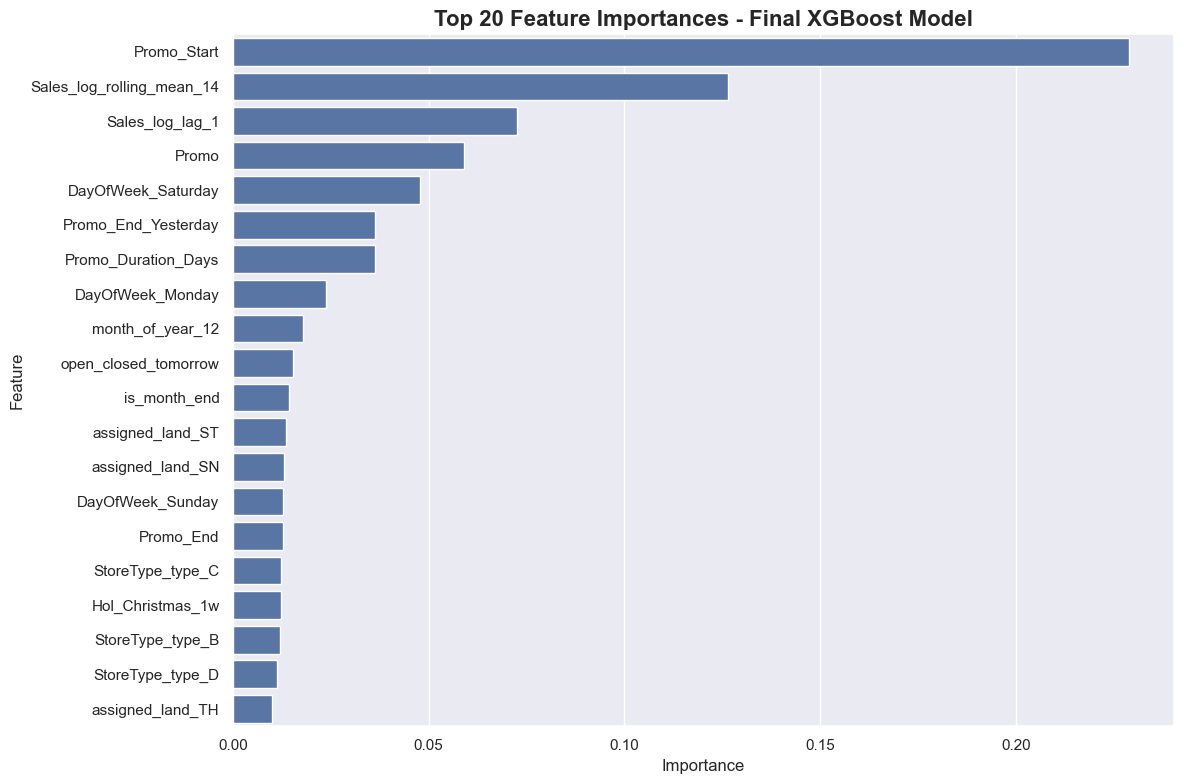

In [81]:
### FEATURE IMPORTANCE - PLOT FOR TOP 20 FEATURES ###

plt.figure(figsize=(12, 8))

sns.barplot(data=feature_importance.head(20),x="Importance",y="Feature")

plt.title("Top 20 Feature Importances - Final XGBoost Model", fontsize = 16, fontweight = "bold")
plt.xlabel("Importance",fontsize = 12)
plt.ylabel("Feature", fontsize = 12)

plt.tight_layout()
plt.show()

### **Observations:**

- Features related to promotions and recent sales history dominate the model. `Promo_Start` (0.23), `Sales_log_rolling_mean_14` (0.13), and `Sales_log_lag_1` (0.07) are among the most influential predictors.

- The importance of `Promo_Start`, `Promo`, `Promo_End_Yesterday`, and `Promo_Duration_Days` suggests that both the timing and duration of promotional campaigns have a substantial impact on sales performance.

- Calendar-related variables such as `DayOfWeek_Saturday`, `DayOfWeek_Monday`, and `month_of_year_12` also contribute to the model, confirming the importance of weekly and seasonal demand patterns.

### 10.2 Predicted vs Actual and Residual Analysis 

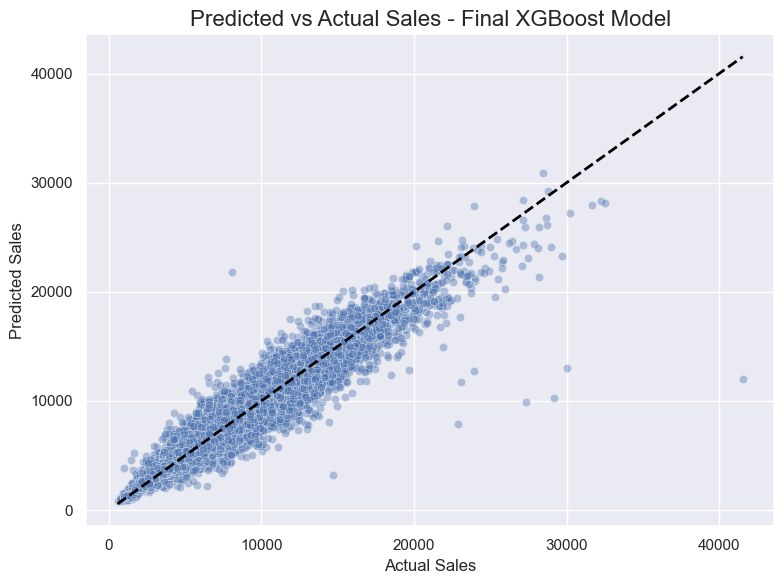

In [82]:
### PREDICTED VS ACTUAL ON TESTING SET ###

# back transformation to original sales scale

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(pd.Series(y_pred_xgb,index=y_test.index))

# SCATTER PLOT - PREDICTED VS ACTUAL SALES (TEST SET)

plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test_real,
                y=y_pred_real,
                alpha=0.4)

plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()],
         linestyle="--", 
         color = "black",
         linewidth = 2)

plt.title("Predicted vs Actual Sales - Final XGBoost Model", fontsize = 16)
plt.xlabel("Actual Sales",fontsize = 12)
plt.ylabel("Predicted Sales",fontsize = 12)

plt.tight_layout()
plt.show()


### **Observations:**

- Most observations are concentrated close to the diagonal line, indicating a **strong agreement between actual and predicted sales values and confirming the model's high predictive accuracy**.

- While several outliers are present and prediction errors become slightly larger for high-sales observations, the overall relationship remains strong across the entire sales range.

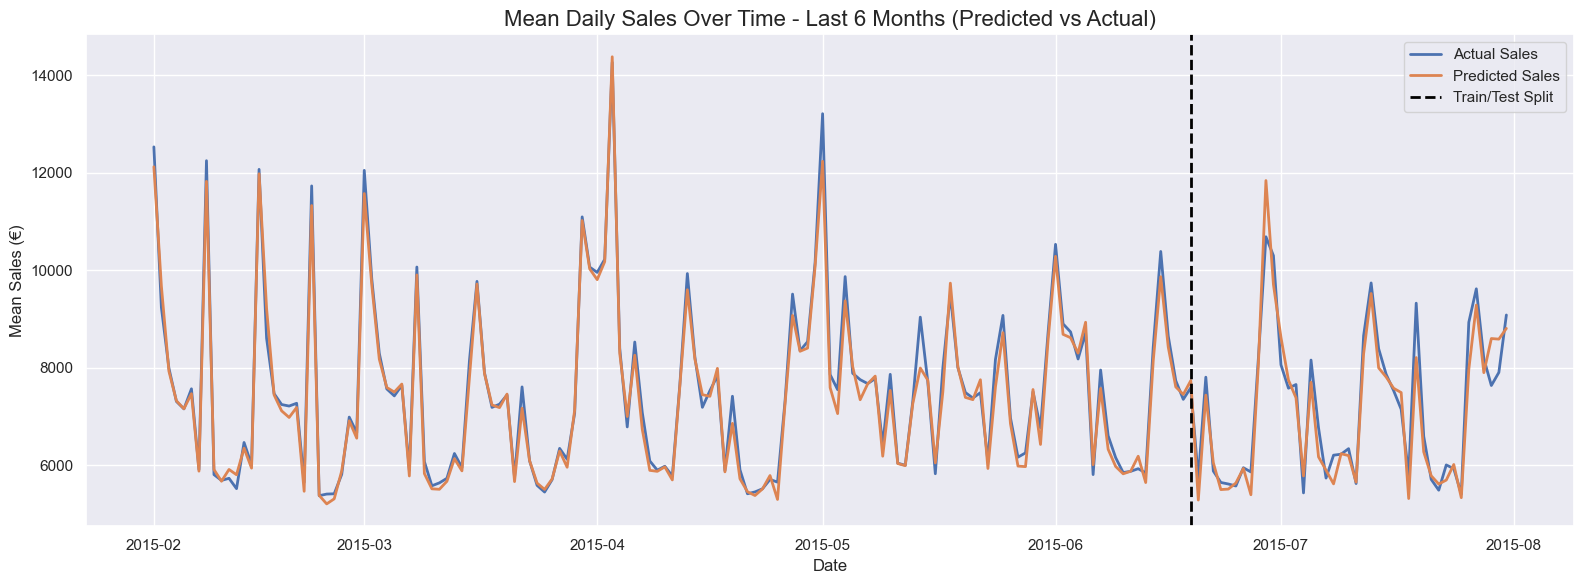

In [84]:
### PREDICTED VS ACTUAL: MEAN SALES OVER TIME (LAST 6 MONTH) ### 

# predictions
y_pred_train = final_model.predict(train_df_tb[features_tb])
y_pred_test = final_model.predict(test_df_tb[features_tb])

# back transformation
train_comparison = pd.DataFrame({
    "Date": train_df_tb["Date"],
    "Actual": np.expm1(train_df_tb["Sales_log"]),
    "Predicted": np.expm1(y_pred_train)
})

test_comparison = pd.DataFrame({
    "Date": test_df_tb["Date"],
    "Actual": np.expm1(test_df_tb["Sales_log"]),
    "Predicted": np.expm1(y_pred_test)
})

# mean sales per day
train_daily = (train_comparison.groupby("Date")[["Actual", "Predicted"]].mean().reset_index())

test_daily = (test_comparison.groupby("Date")[["Actual", "Predicted"]].mean().reset_index())

# last 6 months
cutoff_date = pd.Timestamp("2015-02-01")

# merging train & test results
full_daily = pd.concat([train_daily, test_daily],ignore_index=True)

# zoom for last 6 months
full_daily_zoom = (full_daily.loc[full_daily["Date"] >= cutoff_date])

# plot
plt.figure(figsize=(16, 6))

plt.plot(full_daily_zoom["Date"],
         full_daily_zoom["Actual"],
         label="Actual Sales",
         linewidth=2)

plt.plot(full_daily_zoom["Date"],
         full_daily_zoom["Predicted"],
         label="Predicted Sales",
         linewidth=2)

# train / test split line

plt.axvline(x=test_df_tb["Date"].min(),
            color="black",
            linestyle="--",
            linewidth=2,
            label="Train/Test Split")

plt.title("Mean Daily Sales Over Time - Last 6 Months (Predicted vs Actual)",fontsize = 16)
plt.xlabel("Date", fontsize = 12)
plt.ylabel("Mean Sales (€)", fontsize = 12)
plt.legend()

plt.tight_layout()
plt.show()

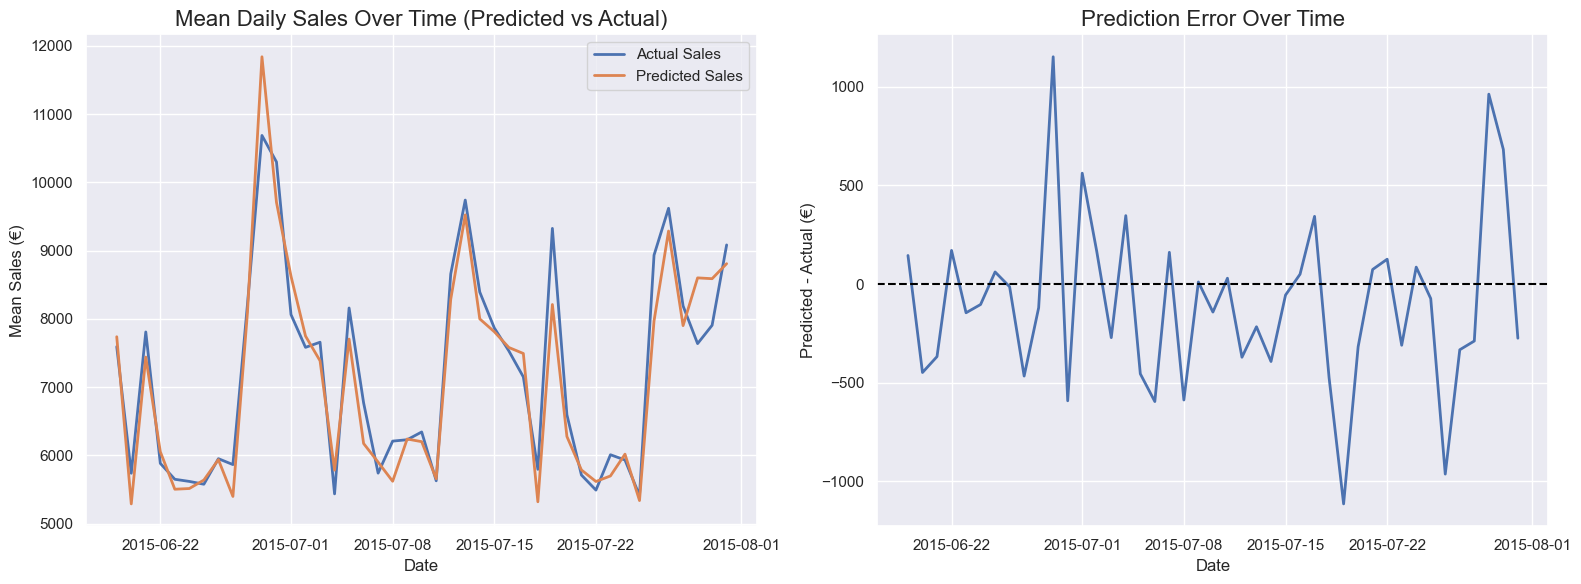

In [85]:
### PREDICTED VS ACTUAL - MEAN SALES OVER TIME & ERROR OVER TIME (TEST SET ONLY) ### 

# additional error calculation

daily_comparison = test_daily.copy()

daily_comparison["Error"] = (daily_comparison["Predicted"] - daily_comparison["Actual"])


fig, axes = plt.subplots(1,2,figsize=(16, 6))

# Predicted vs Actual Mean Sales Over Time

axes[0].plot(daily_comparison["Date"],
             daily_comparison["Actual"],
             label="Actual Sales",
             linewidth=2)

axes[0].plot(daily_comparison["Date"],
             daily_comparison["Predicted"],
             label="Predicted Sales",
             linewidth=2)

axes[0].set_title("Mean Daily Sales Over Time (Predicted vs Actual)", fontsize = 16)
axes[0].set_xlabel("Date", fontsize = 12)
axes[0].set_ylabel("Mean Sales (€)", fontsize = 12)
axes[0].legend()

# Prediction Error Over Time 

axes[1].plot(daily_comparison["Date"],
             daily_comparison["Error"],
             linewidth=2)

axes[1].axhline(y=0,
                linestyle="--",
                color = "black")

axes[1].set_title("Prediction Error Over Time", fontsize = 16)
axes[1].set_xlabel("Date", fontsize = 12)
axes[1].set_ylabel("Predicted - Actual (€)", fontsize = 12)

plt.tight_layout()
plt.show()

### **Observations:**

- The predicted sales *(orange line; first chart)* closely follow the actual sales *(blue line; first chart)* throughout the entire testing period, indicating that **the model successfully captures both the overall sales level and short-term fluctuations**.

- No prolonged periods of systematic overestimation or underestimation are visible, suggesting that the **model generalizes well and does not exhibit a strong prediction bias**. Moreover, the lack of a visible performance shift after the train-test split provides additional evidence that the model remains stable when applied to unseen observations.

- Prediction errors fluctuate around zero and appear reasonably random over time, indicating that the **most important temporal and seasonal patterns have been successfully captured** by the model.

- Although several individual days exhibit larger forecasting errors, these deviations are **isolated rather than systematic** and therefore do not suggest a structural weakness of the model.

- The model is able to capture both sales peaks and sales declines reasonably well, suggesting that **promotional, calendar-related, and seasonality features effectively explain major demand fluctuations**.

In [ ]:
# 10 days with the most overestimated turnover

daily_comparison.sort_values(by="Error",ascending=False).nlargest(10, columns="Error")

,Date,Actual,Predicted,Error
10,2015-06-29,10687.5982,11840.7002,1153.1020
40,2015-07-29,7636.9829,8600.4121,963.4292
41,2015-07-30,7905.5292,8588.3496,682.8204
12,2015-07-01,8062.4861,8624.9668,562.4807
15,2015-07-04,5434.7181,5781.7993,347.0812
28,2015-07-17,7148.6844,7492.1016,343.4172
3,2015-06-22,5881.9910,6052.7041,170.7131
13,2015-07-02,7581.9506,7747.5376,165.5870
18,2015-07-07,5738.8007,5899.7637,160.9630
0,2015-06-19,7592.6858,7737.5962,144.9104


In [ ]:
# 10 days with the most underestimated turnover

daily_comparison.sort_values(by="Error").nsmallest(10, columns="Error")

,Date,Actual,Predicted,Error
30,2015-07-19,9325.5625,8210.0273,-1115.5352
37,2015-07-26,8933.2812,7968.9600,-964.3213
17,2015-07-06,6768.8268,6172.6802,-596.1466
11,2015-06-30,10299.4906,9707.1582,-592.3324
19,2015-07-08,6207.9219,5619.5322,-588.3897
29,2015-07-18,5794.2336,5318.9229,-475.3108
8,2015-06-27,5863.9587,5397.0469,-466.9119
16,2015-07-05,8159.0303,7703.5229,-455.5074
1,2015-06-20,5736.6795,5287.8101,-448.8695
25,2015-07-14,8392.0979,7999.1040,-392.9939


In [ ]:
# in the next step of the analysis, it could be checked what exactly these top 10 days with the most overestimated/underestimated sales are 
# (e.g., day of the week, proximity of holidays and promotions, etc.)

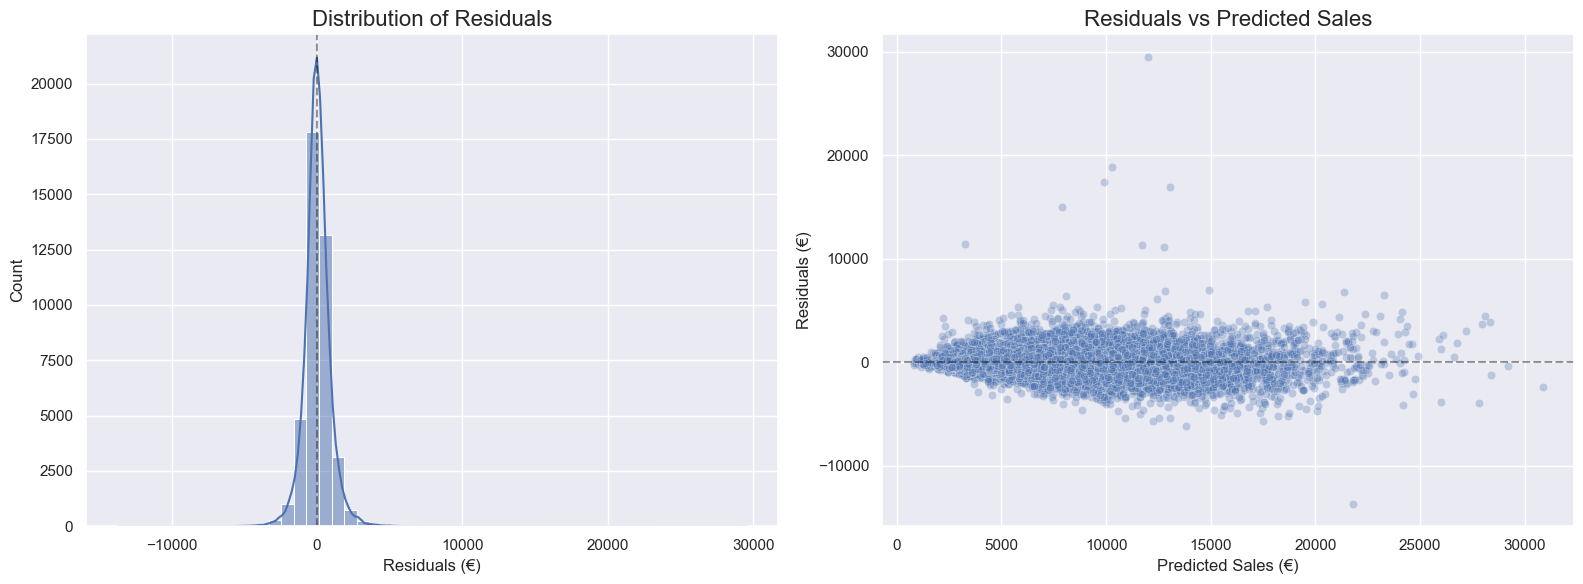

In [86]:
### RESIDUAL ANALYSIS ###

residuals = y_test_real - y_pred_real

residual_df = pd.DataFrame({
    "Date": test_df_tb.loc[y_test.index, "Date"],
    "Actual": y_test_real,
    "Predicted": y_pred_real,
    "Residual": residuals,
    "Abs_Error": np.abs(residuals),
    "APE": np.abs(residuals / y_test_real)
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residual Distribution

sns.histplot(residual_df["Residual"],
             bins=50,
             kde=True,ax=axes[0])

axes[0].axvline(0, linestyle="--", color="black", alpha = 0.4)

axes[0].set_title("Distribution of Residuals", fontsize = 16)
axes[0].set_xlabel("Residuals (€)", fontsize = 12)
axes[0].set_ylabel("Count", fontsize = 12)

# Residuals vs Predicted

sns.scatterplot(x=residual_df["Predicted"],
                y=residual_df["Residual"],
                alpha=0.3,
                ax=axes[1])

axes[1].axhline(0, linestyle="--", color="black", alpha = 0.4)

axes[1].set_title("Residuals vs Predicted Sales", fontsize = 16)
axes[1].set_xlabel("Predicted Sales (€)", fontsize = 12)
axes[1].set_ylabel("Residuals (€)", fontsize = 12)

plt.tight_layout()
plt.show()

### **Observations:**

- Residuals are concentrated around zero, suggesting that the model **does not exhibit a substantial systematic bias**. Most prediction errors are relatively small, while only a limited number of observations generate large deviations.

- Residuals appear reasonably randomly distributed across the range of predicted sales, indicating that the **model performs consistently** across different sales levels.

- A slight **increase in residual variability** can be observed for **higher predicted sales values**. It suggests that larger stores exhibit greater absolute fluctuations in demand.

- Although several **outliers** are present, **no strong patterns** suggesting model misspecification or systematic over- or underestimation are **visible**.

In [ ]:
# 10 observations with the largest difference in sales (€) between prediction and reality (|Actual - Predicted|)

residual_df.sort_values("Abs_Error",ascending=False).head(10) # Abs_Error - errors in sales units

,Date,Actual,Predicted,Residual,Abs_Error,APE
687678,2015-06-22,41551.0000,15063.1973,26487.8027,26487.8027,0.6375
219841,2015-06-29,29161.0000,10425.2793,18735.7207,18735.7207,0.6425
663394,2015-07-06,27330.0000,9081.7295,18248.2705,18248.2705,0.6677
687679,2015-06-23,30038.0000,13774.7676,16263.2324,16263.2324,0.5414
687684,2015-06-29,6125.0000,22015.4277,-15890.4277,15890.4277,2.5944
687677,2015-06-20,22882.0000,8918.6006,13963.3994,13963.3994,0.6102
687687,2015-07-18,16051.0000,3692.3235,12358.6765,12358.6765,0.7700
663393,2015-07-04,14708.0000,3657.2966,11050.7034,11050.7034,0.7513
663395,2015-07-07,23927.0000,12912.1016,11014.8984,11014.8984,0.4604
687688,2015-07-20,23081.0000,13298.1543,9782.8457,9782.8457,0.4238


In [ ]:
# 10 observations with the largest percentage difference between prediction and reality (|Actual - Predicted| / |Actual|)

residual_df.sort_values("APE",ascending=False).head(10) # APE - percentage errors

,Date,Actual,Predicted,Residual,Abs_Error,APE
687684,2015-06-29,6125.0000,22015.4277,-15890.4277,15890.4277,2.5944
591649,2015-06-26,1422.0000,4468.5781,-3046.5781,3046.5781,2.1425
219846,2015-07-04,1646.0000,5123.1084,-3477.1084,3477.1084,2.1125
219851,2015-07-10,1012.0000,2457.3010,-1445.3010,1445.3010,1.4282
767623,2015-07-25,2954.0000,6322.4722,-3368.4722,3368.4722,1.1403
219849,2015-07-08,2406.0000,5126.7256,-2720.7256,2720.7256,1.1308
379482,2015-07-25,1571.0000,3268.7483,-1697.7483,1697.7483,1.0807
463801,2015-07-01,4256.0000,8346.6436,-4090.6436,4090.6436,0.9611
663400,2015-07-13,8088.0000,15600.3428,-7512.3428,7512.3428,0.9288
841237,2015-07-01,3701.0000,7080.0610,-3379.0610,3379.0610,0.9130


In [ ]:
# as the next step of debugging the model, it could be investigated what are the characteristics of the observations for which the model was most wrong (types of stores, periods, location, etc.)

### 10.3. SHAP

In [ ]:
# SHAP analysis is used to quantify how individual features contribute to model predictions. 
# For each observation, SHAP values indicate how much a given variable increases or decreases the prediction relative to the model's average output.

# Compared with traditional feature importance measures, SHAP provides a more informative interpretation of model behavior. 
# Feature importance indicates how frequently and how effectively a variable was used to improve tree splits during training, 
# whereas SHAP measures the actual impact of each feature on the final predictions.

# SHAP => debugging + explanation + data exploration

In [ ]:
# SHAP

import shap

preprocessor = final_model.named_steps["preprocessor"]
xgb_model = final_model.named_steps["model"]

X_test = test_df_tb[features_tb]
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_test_processed, "toarray"): X_test_processed = X_test_processed.toarray()

feature_names = preprocessor.get_feature_names_out()

feature_names_clean = (pd.Series(feature_names)
                       .str.replace("remainder__", "", regex=False)
                       .str.replace("cat__", "", regex=False)
                       .str.replace("num__", "", regex=False))

X_test_processed_df = pd.DataFrame(X_test_processed,
                                   columns=feature_names_clean,
                                   index=X_test.index)

# X_shap = X_test_processed_df.sample(n=min(5000, len(X_test_processed_df)),random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_processed_df)

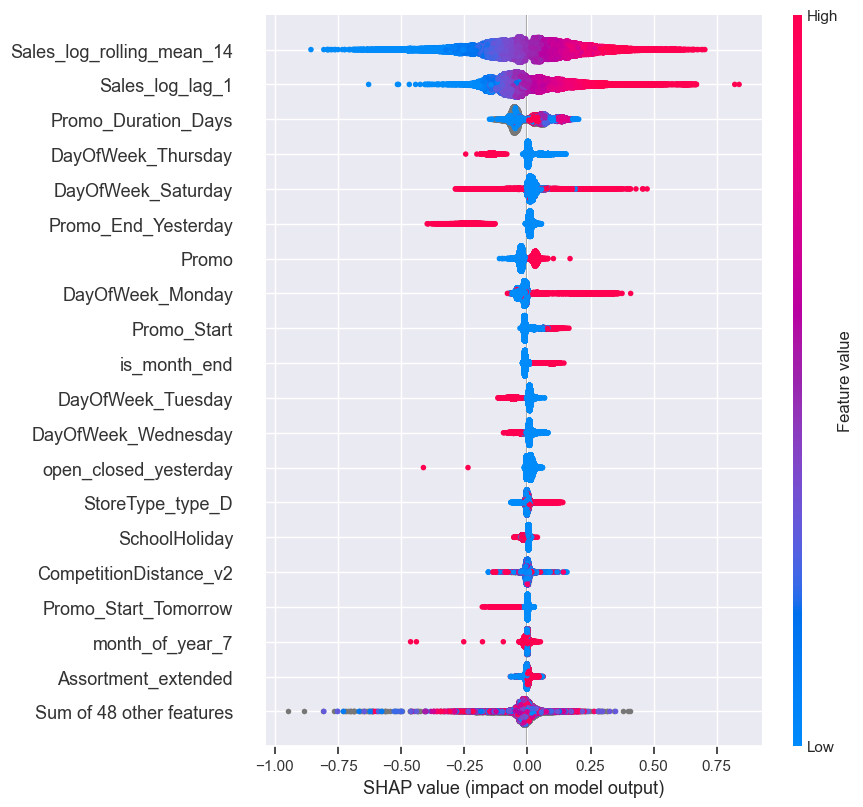

In [ ]:
# How does a given feature affect individual observations? - TOP 20

shap.plots.beeswarm(shap_values, max_display=20)

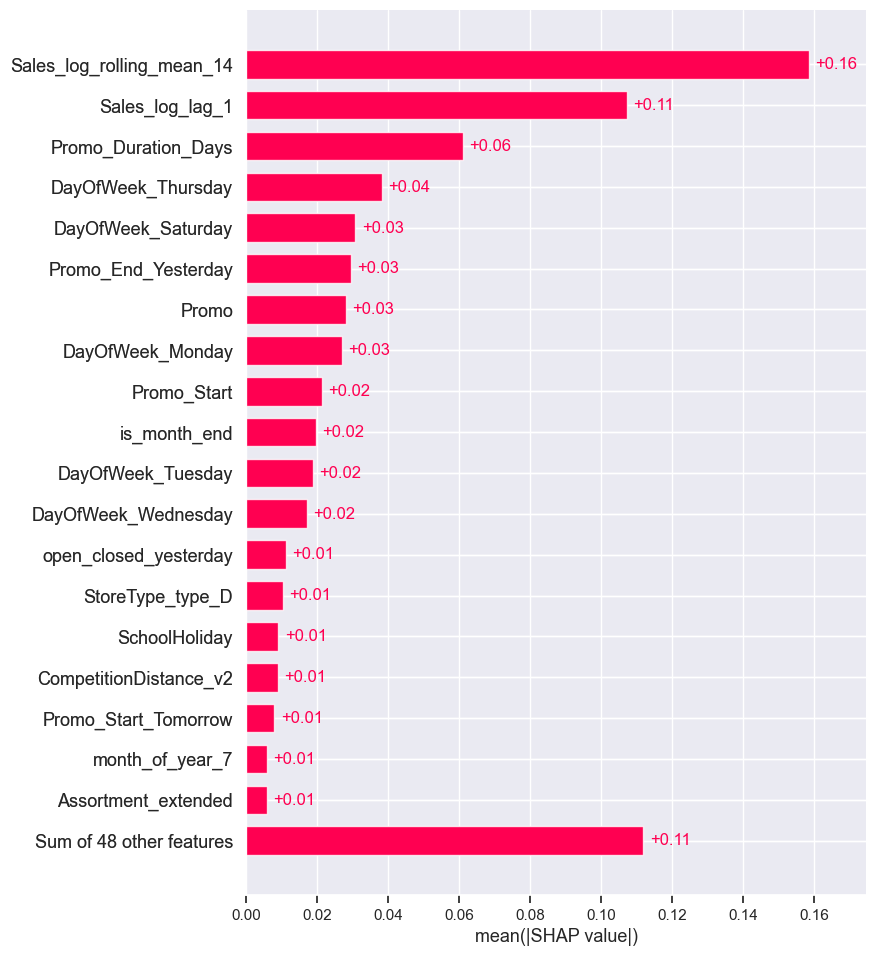

In [ ]:
# How strongly does a given feature influence the model? - TOP20 

shap.plots.bar(shap_values, max_display=20)

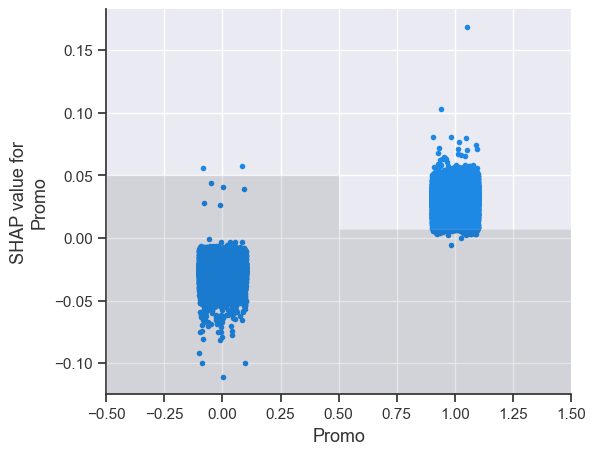

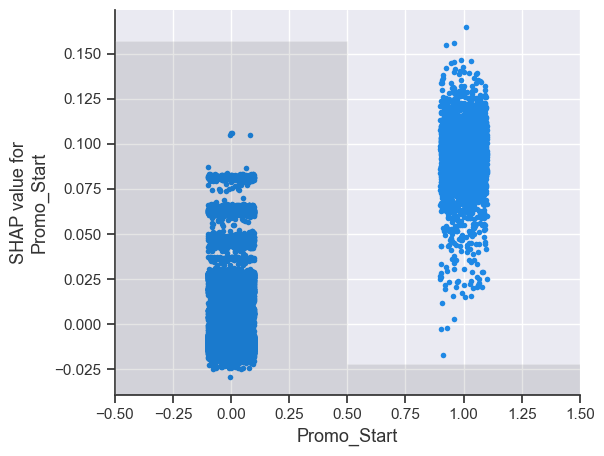

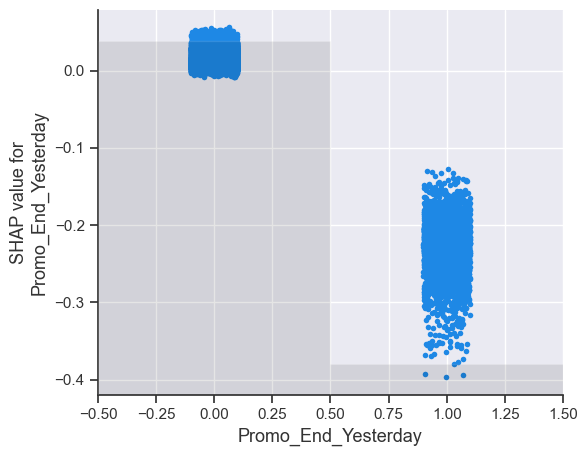

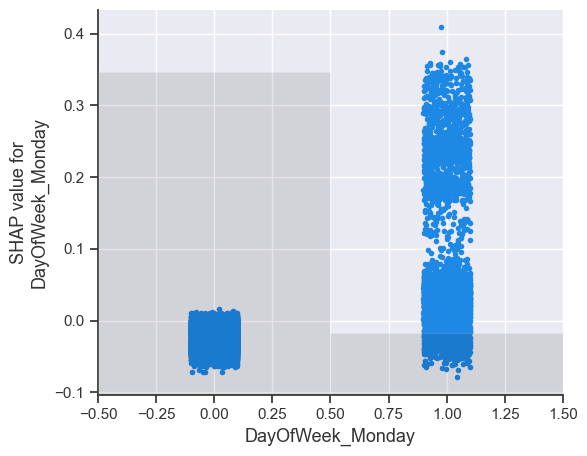

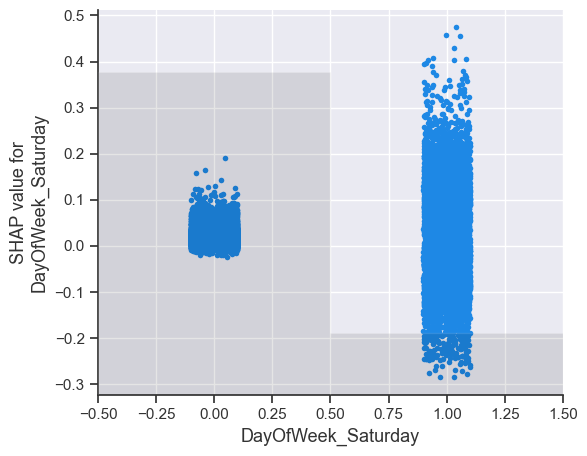

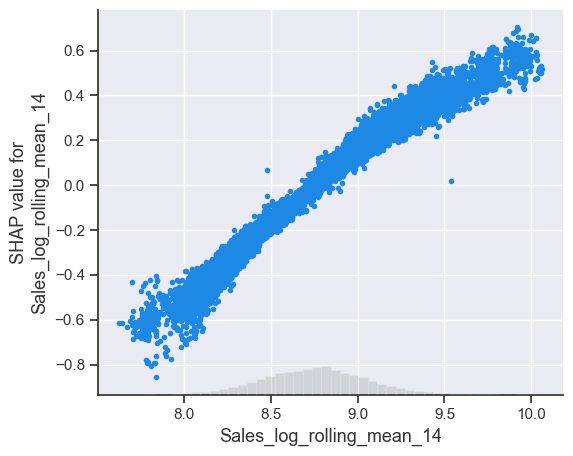

In [ ]:
# What is the value of SHAP depending on the values ​​of selected variables? 

shap.plots.scatter(shap_values[:, "Promo"]) 

shap.plots.scatter(shap_values[:, "Promo_Start"])

shap.plots.scatter(shap_values[:, "Promo_End_Yesterday"])

shap.plots.scatter(shap_values[:, "DayOfWeek_Monday"])

shap.plots.scatter(shap_values[:, "DayOfWeek_Saturday"])

shap.plots.scatter(shap_values[:, "Sales_log_rolling_mean_14"])


### **Key Findings:**

- Recent sales history is the **strongest source of predictive information**, with `Sales_log_rolling_mean_14` and `Sales_log_lag_1` having the largest impact on model predictions.

- **Promotional activity plays a major role in explaining sales variability**, with both promotion timing (e.g., `Promo_Start`, `Promo_End_Yesterday`) and promotion duration (`Promo_Duration_Days`) contributing substantially to forecast accuracy.

- **Calendar effects remain important** even after accounting for promotions and sales history, indicating persistent **weekly and monthly purchasing patterns**.

- Overall, the SHAP results are **highly consistent** with the findings from correlation analysis, baseline models, feature importance analysis, and recursive forecasting, providing additional confidence in the robustness of the identified sales drivers.